# Importation

In [27]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.colors import LinearSegmentedColormap
%matplotlib inline

from pathlib import Path

# Baseline 
from sklearn.linear_model import PoissonRegressor

# ML
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import SGDRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import learning_curve

from sklearn.base import clone
import joblib
from joblib import Memory

# Training performance evaluation
import os
import time
import io
import threading
from datetime import datetime 

# Model interpretation
import shap
import scipy.sparse as sp
from sklearn.inspection import PartialDependenceDisplay


try:
    import psutil
    _HAS_PSUTIL = True
except ImportError:
    psutil = None
    _HAS_PSUTIL = False

## Data loading

In [28]:
base_path = Path("..") / "Data" / "processed"

df_feature_1 = pd.read_csv(base_path / 'data_df_feature_1.csv',delimiter=',')
df_feature_2 = pd.read_csv(base_path / 'data_df_feature_2.csv',delimiter=',')


df_feature_1.drop(columns="Unnamed: 0",inplace= True)
df_feature_2.drop(columns="Unnamed: 0",inplace= True)


In [29]:
print("=== Head of df_feature_2 ===")
print(df_feature_1.head(), "\n")

print("=== Column names ===")
print(df_feature_1.columns.tolist(), "\n")

print("=== DataFrame info ===")
df_feature_1.info()

=== Head of df_feature_2 ===
         DATE  Style  quantity   price Category  log_price  dlog_qty_SKU  \
0  2021-01-07  J0004         1  1234.0      Set   7.118016           NaN   
1  2021-01-07  J0004         1  1234.0      Set   7.118016           NaN   
2  2021-01-07  J0004         1  1234.0      Set   7.118016           NaN   
3  2021-01-07  J0004         1  1234.0      Set   7.118016           NaN   
4  2021-01-07  J0004         1  1234.0      Set   7.118016           NaN   

   dlog_price_SKU  elasticite_rolling_SKU  dlog_qty_Style  ...  \
0             NaN                     0.0             NaN  ...   
1             NaN                     0.0             NaN  ...   
2             NaN                     0.0             0.0  ...   
3             NaN                     0.0             0.0  ...   
4             NaN                     0.0             0.0  ...   

   basket_intensity_style_norm  basket_intensity_style_norm_plot  year  \
0                          1.0             

In [30]:
print("=== Head of df_feature_2 ===")
print(df_feature_2.head(), "\n")

print("=== Column names ===")
print(df_feature_2.columns.tolist(), "\n")

print("=== DataFrame info ===")
df_feature_2.info()

=== Head of df_feature_2 ===
         DATE Category  quantity       price  saison    year  month_sin  \
0  2021-05-06   Blouse         3  411.016667     0.0  2021.0        0.5   
1  2021-05-07   Blouse         0         NaN     NaN     NaN        NaN   
2  2021-05-08   Blouse         0         NaN     NaN     NaN        NaN   
3  2021-05-09   Blouse         0         NaN     NaN     NaN        NaN   
4  2021-05-10   Blouse         0         NaN     NaN     NaN        NaN   

   month_cos  week_sin  week_cos  ...  roll_mean_7  roll_std_7  roll_mean_14  \
0  -0.866025  0.822984 -0.568065  ...     0.000000    0.000000      0.000000   
1        NaN       NaN       NaN  ...     0.428571    1.133893      0.214286   
2        NaN       NaN       NaN  ...     0.428571    1.133893      0.214286   
3        NaN       NaN       NaN  ...     0.428571    1.133893      0.214286   
4        NaN       NaN       NaN  ...     0.428571    1.133893      0.214286   

   roll_std_14  roll_mean_28  roll_std_

- Convert DATE columns to datetime

In [31]:
liste_df = [df_feature_1, df_feature_2]

for df in liste_df:
    df["DATE"] = pd.to_datetime(
        df["DATE"],
        format="%d-%m-%y",
        errors="coerce"
    )

    df["DATE"] = df["DATE"].ffill()

    print(f"Check the dtype of DATE after conversion : {df['DATE'].dtype}")

Check the dtype of DATE after conversion : datetime64[ns]
Check the dtype of DATE after conversion : datetime64[ns]


# Pre proccessing

- Organisation des features

In [32]:
# Categorical variable

cat_features_f1 = ['Style', 'Category', 'saison']
cat_features_f2 = ['Category', 'saison']

# Numeric variables
num_features_f1 = [
       'price',
       'log_price',
       'dlog_qty_SKU',
       'dlog_price_SKU',
       'dlog_qty_Style',
       'dlog_price_Style',
       'dlog_qty_Category',
       'dlog_price_Category',
       'elasticite_rolling_SKU',
       'elasticite_rolling_Style',
       'elasticite_rolling_Category',
       'var_elasticite_rolling_SKU',
       'var_elasticite_rolling_Style',
       'var_elasticite_rolling_Category'

       ]
num_features_f2 = ['price',
       'roll_mean_7', 
       'roll_std_7', 
       'roll_mean_14', 
       'roll_std_14',
       'roll_mean_28', 
       'roll_std_28', 
       'lag_1', 
       'lag_7', 
       'lag_14', 
       'lag_28',
       'log_price',
       'dlog_qty_SKU',
       'dlog_price_SKU',
       'dlog_qty_Style',
       'dlog_price_Style',
       'dlog_qty_Category',
       'dlog_price_Category',
       'elasticite_rolling_SKU',
       'elasticite_rolling_Style',
       'elasticite_rolling_Category',
       'var_elasticite_rolling_SKU',
       'var_elasticite_rolling_Style',
       'var_elasticite_rolling_Category'

       ]

pas_transf = [
       'year',
       'flag_imputed_elasticite_rolling_SKU',
       'flag_imputed_var_elasticite_rolling_SKU',
       'flag_imputed_elasticite_rolling_Category',
       'flag_imputed_var_elasticite_rolling_Category',
       'flag_imputed_elasticite_rolling_Style',
       'flag_imputed_var_elasticite_rolling_Style'

       ]

# Cyclic variables
cyclic_features_f1 = ['month_sin', 'month_cos', 'week_sin', 'week_cos', 'day_sin', 'day_cos'] 
cyclic_features_f2 = ['month_sin', 'month_cos', 'week_sin', 'week_cos', 'day_sin', 'day_cos'] 

# Verification that all variables are ranked
col_f1 = set(cat_features_f1) | set(num_features_f1) | set(cyclic_features_f1) | set(pas_transf)
col_f2 = set(cat_features_f2) | set(num_features_f2) | set(cyclic_features_f2) | set(pas_transf)

df_col_f1 = set(df_feature_1.columns)
df_col_f2 = set(df_feature_2.columns)

non_preproc_f1 =df_col_f1 - set(col_f1)
non_preproc_f2 =df_col_f2 - set(col_f2)

display(non_preproc_f1)
display(non_preproc_f2)

{'DATE',
 'basket_intensity_style_norm',
 'basket_intensity_style_norm_plot',
 'quantity',
 'style_mean_qty'}

{'DATE', 'quantity'}

In [33]:
def preprocessor(cat_features, num_features, cyclic_features, non_transf):
    """
    Build a preprocessing pipeline for machine learning features.

    Args:
        cat_features (list): Categorical features to encode with OneHotEncoder.
        num_features (list): Numerical features to scale.
        cyclic_features (list): Cyclic features (e.g., sin/cos time encoding).
        non_transf (list): Features kept without scaling.

    Returns:
        ColumnTransformer: Preprocessing object ready for a scikit-learn pipeline.
    """

    # Pipeline for numerical features
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    # Pipeline for passthrough features
    passthrough_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent"))
    ])

    # Pipeline for categorical features
    cat_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    # Pipeline for cyclic features
    cyclic_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    # Combine all transformers
    preproc = ColumnTransformer(
        transformers=[
            ("cat", cat_transformer, cat_features),
            ("num", numeric_transformer, num_features),
            ("pas_transf", passthrough_transformer, non_transf),
            ("cyclic", cyclic_transformer, cyclic_features),
        ],
        remainder="drop"
    )

    return preproc


## Split du dataset

In [34]:
def split(df, target="quantity", date_col="DATE", train_size=0.70, val_size=0.15, n_splits=5):
    """
    Perform a deterministic temporal split for ML training and evaluation.

    Args:
        df (DataFrame): Dataset containing features and target.
        target (str): Target variable.
        date_col (str): Column used to sort the dataset chronologically.
        train_size (float): Proportion of training data.
        val_size (float): Proportion of validation data.
        n_splits (int): Number of folds for TimeSeriesSplit.

    Returns:
        dict: Train/validation/test datasets and TimeSeriesSplit object.
    """

    df = df.copy()

    if date_col is not None:
        df = df.sort_values(date_col)

    # Separate features and target
    X = df.drop(columns=[target])
    y = df[target]

    # Compute split indices
    n = len(df)
    train_end = int(n * train_size)
    val_end = int(n * (train_size + val_size))

    # Create training set
    X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]

    # Create validation set
    X_val, y_val = X.iloc[train_end:val_end], y.iloc[train_end:val_end]

    # Create test set
    X_test, y_test = X.iloc[val_end:], y.iloc[val_end:]

    # Build tuning dataset (train + validation)
    X_tune = X.iloc[:val_end]
    y_tune = y.iloc[:val_end]

    test_size = int(0.15 * len(X_tune))

    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)

    return {
        "X_tune": X_tune, "y_tune": y_tune, "tscv": tscv,
        "X_train": X_train, "y_train": y_train,
        "X_val": X_val, "y_val": y_val,
        "X_test": X_test, "y_test": y_test,
        "train_end": train_end, "val_end": val_end,
        "X": X, "y": y
    }


# Model evaluation tools


## Metrics analysis

-   Compare datasets

In [35]:
def _draw_glow_line(ax, x, y, color, label=None):
    """
    Draw a glowing line with highlighted markers.

    Args:
        ax: Matplotlib axis.
        x: X values.
        y: Y values.
        color (str): Line color.
        label (str | None): Legend label.
    """

    # Glow layer
    ax.plot(
        x, y,
        color=color,
        linewidth=7,
        alpha=0.12,
        solid_capstyle="round",
        zorder=1
    )

    # Main line
    ax.plot(
        x, y,
        color=color,
        linewidth=2.6,
        marker="o",
        markersize=7,
        markerfacecolor="#05070F",
        markeredgecolor=color,
        markeredgewidth=1.8,
        label=label,
        zorder=3
    )

    # Marker halo
    ax.scatter(
        x, y,
        s=180,
        color=color,
        alpha=0.10,
        zorder=2
    )


def plot_best_df(best_df):
    """
    Plot normalized metrics for the best model of each dataset.

    Args:
        best_df: DataFrame containing best model metrics by dataset.
    """

    palette = {
        "FIG_BG": "#05070F",
        "AX_BG": "#05070F",
        "GRID": "#FFFFFF",
        "TEXT": "#D6E3FF",
        "TITLE": "#E6EDFF",
        "XTICK": "#9FB3FF",
        "YTICK": "#9FB3FF",
        "LABEL_BOX_FACE": "#0F172A",
        "LABEL_BOX_EDGE": "#38BDF8",
        "GOOD": "#22C55E",
        "BAD": "#EF4444",
    }

    metrics = ["CV_MAE", "CV_RMSE", "TEST_MAE", "TEST_RMSE"]

    # Reshape to long format
    long = best_df.melt(
        id_vars=["dataset", "best_model"],
        value_vars=metrics,
        var_name="metric",
        value_name="value"
    )

    # Normalize values by metric
    long["value_norm"] = long.groupby("metric")["value"].transform(
        lambda x: x / x.max()
    )

    # Compute average normalized score by dataset
    score = (
        long.groupby("dataset")["value_norm"]
        .mean()
        .sort_values()
    )

    best_dataset = score.index[0]
    worst_dataset = score.index[-1]

    fig, ax = plt.subplots(figsize=(11, 5))
    fig.patch.set_facecolor(palette["FIG_BG"])
    ax.set_facecolor(palette["AX_BG"])

    x = np.arange(len(metrics))

    for ds in best_df["dataset"].unique():
        sub = long[long["dataset"] == ds].copy()
        sub = sub.set_index("metric").loc[metrics].reset_index()

        y = sub["value_norm"].values
        model = sub["best_model"].iloc[0]

        # Choose color by ranking
        if ds == worst_dataset:
            color = palette["BAD"]
        elif ds == best_dataset:
            color = palette["GOOD"]
        else:
            color = "#38BDF8"

        _draw_glow_line(
            ax,
            x,
            y,
            color=color,
            label=ds
        )

        # Model label
        ax.text(
            x[-1] + 0.08,
            y[-1],
            model,
            va="center",
            fontsize=9,
            color=palette["TEXT"],
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor=palette["LABEL_BOX_FACE"],
                edgecolor=color,
                linewidth=1.2
            )
        )

    ax.set_title(
        "Best model par dataset - normalized metrics",
        color=palette["TITLE"],
        fontsize=14,
        fontweight="bold",
        pad=12
    )

    ax.set_xlabel("Metrics", color=palette["TEXT"])
    ax.set_ylabel("Normalized values", color=palette["TEXT"])

    ax.set_xticks(x)
    ax.set_xticklabels(metrics, color=palette["XTICK"])
    ax.set_ylim(-0.05, 1.05)

    ax.grid(axis="y", color=palette["GRID"], alpha=0.18)
    ax.grid(axis="x", visible=False)

    ax.tick_params(axis="y", colors=palette["YTICK"], length=0)
    ax.tick_params(axis="x", colors=palette["XTICK"], length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

    legend = ax.legend(title="Dataset", frameon=False)
    legend.get_title().set_color(palette["TEXT"])

    for text in legend.get_texts():
        text.set_color(palette["TEXT"])

    plt.tight_layout()
    plt.show()

In [36]:
def resume_ent_model(
    grid,
    X_fit, y_fit,
    X_test, y_test,
    select_metric="MAE",
    dataset_name="dataset",
    sort_by="TEST_MAE"
):
    """
    Summarize best model per family from a GridSearchCV and evaluate on test set.

    Args:
        grid: Fitted GridSearchCV with MAE and RMSE scoring.
        X_fit: Training features.
        y_fit: Training target.
        X_test: Test features.
        y_test: Test target.
        select_metric (str): Metric used to select best model ("MAE" or "RMSE").
        dataset_name (str): Dataset name for reporting.
        sort_by (str | None): Column used to sort results.

    Returns:
        pd.DataFrame: Summary of CV and test metrics per model.
    """

    # Convert GridSearch results to DataFrame
    cv = pd.DataFrame(grid.cv_results_).copy()

    # Validate required metrics
    required = ["mean_test_MAE", "mean_test_RMSE"]
    for c in required:
        if c not in cv.columns:
            raise ValueError("GridSearch doit être multi-métriques: scoring {'MAE', 'RMSE'} requis.")

    # Ensure the param_grid contains 'model'
    if "param_model" not in cv.columns:
        raise ValueError("param_model absent : ta param_grid doit contenir la clé 'model'.")

    # Convert sklearn negative scores to positive metrics
    cv["CV_MAE"] = -cv["mean_test_MAE"]
    cv["CV_MAE_STD"] = cv["std_test_MAE"].abs() if "std_test_MAE" in cv.columns else np.nan

    cv["CV_RMSE"] = -cv["mean_test_RMSE"]
    cv["CV_RMSE_STD"] = cv["std_test_RMSE"].abs() if "std_test_RMSE" in cv.columns else np.nan

    # Extract model family name
    cv["model_name"] = cv["param_model"].apply(lambda m: type(m).__name__)

    # Select best configuration per model family
    select_metric = select_metric.upper()
    if select_metric not in ["MAE", "RMSE"]:
        raise ValueError("select_metric doit être 'MAE' ou 'RMSE'.")

    sel_col = "CV_MAE" if select_metric == "MAE" else "CV_RMSE"

    idx_best = cv.groupby("model_name")[sel_col].idxmin()
    best_rows = cv.loc[idx_best].copy()

    # Refit best configuration and evaluate on test set
    rows = []
    for _, r in best_rows.iterrows():

        est = clone(grid.estimator)
        est.set_params(**r["params"])
        est.fit(X_fit, y_fit)

        y_pred = est.predict(X_test)

        rows.append({
            "model_name": r["model_name"],
            "dataset": dataset_name,

            # CV metrics
            "CV_MAE": r["CV_MAE"],
            "CV_MAE_STD": r["CV_MAE_STD"],
            "CV_RMSE": r["CV_RMSE"],
            "CV_RMSE_STD": r["CV_RMSE_STD"],

            # Test metrics
            "TEST_MAE": mean_absolute_error(y_test, y_pred),
            "TEST_RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),

            "best_params": r["params"],
        })

    out = pd.DataFrame(rows)

    if sort_by is not None:
        if sort_by not in out.columns:
            raise ValueError(f"sort_by='{sort_by}' introuvable. Colonnes possibles: {list(out.columns)}")
        out = out.sort_values(sort_by, ascending=True).reset_index(drop=True)

    return out

-   Visualisation

In [37]:
def plot_cv(
    recap_df,
    dataset="df_feature_1",
    models=None,
    sort_by="CV_MAE",
    ascending=True,
    figsize=(12, 4.8),
    xrotation=20,
    title_color="#E6EDFF",
    palette=None
):
    """
    Plot cross-validation performance (mean and std) for ML models.

    Args:
        recap_df (DataFrame): Summary DataFrame with CV metrics.
        dataset (str): Dataset name to filter results.
        models: Model selection (int, list, or regex).
        sort_by (str): Column used to sort models.
        ascending (bool): Sort order.
        figsize (tuple): Figure size.
        xrotation (int): Rotation angle for x-axis labels.
        title_color (str): Title color.
        palette (dict): Custom color palette.

    Returns:
        None: Displays matplotlib plots.
    """

    
    if palette is None:
        palette = {
            "FIG_BG": "#05070F",
            "AX_BG": "#05070F",
            "GRID": "#FFFFFF",
            "TEXT": "#D6E3FF",
            "TITLE": "#E6EDFF",
            "XTICK": "#9FB3FF",
            "YTICK": "#9FB3FF",
            "MAE": "#2563EB",
            "RMSE": "#0A84FF",
            "ERR": "#94A3B8",
        }

    
    df = recap_df[recap_df["dataset"] == dataset].copy()

    # Filter models based on input type
    if models is not None:
        if isinstance(models, int):
            pass  
        elif isinstance(models, (list, tuple, set)):
            df = df[df["model_name"].isin(list(models))].copy()
        elif isinstance(models, str):
            df = df[df["model_name"].astype(str).str.contains(models, regex=True, na=False)].copy()
        else:
            raise TypeError("models must be None, int, list/tuple/set, or regex string.")

# Validate sorting column
    if sort_by not in df.columns:
        raise ValueError(f"Missing column '{sort_by}' in recap_df.")

    
    df = df.sort_values(sort_by, ascending=ascending).reset_index(drop=True)

    # Keep top N models if models is an integer
    if isinstance(models, int):
        df = df.head(models).copy()

    # Create figure and subplots
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.patch.set_facecolor(palette["FIG_BG"])

    # Loop over MAE and RMSE
    for ax, metric in zip(axes, ["MAE", "RMSE"]):

        # Define column names
        cv_col = f"CV_{metric}"
        std_col = f"CV_{metric}_STD"

        # Extract values
        x = np.arange(len(df))
        cv_vals = df[cv_col].values
        std_vals = df[std_col].values

        ax.set_facecolor(palette["AX_BG"])

        # Plot CV mean with error bars (std)
        ax.errorbar(
            x,
            cv_vals,
            yerr=std_vals,
            fmt="o",
            color=palette[metric],
            ecolor=palette["ERR"],
            elinewidth=1.6,
            capsize=5,
            markersize=7,
            label=f"CV {metric}",
            zorder=3
        )

        # Connect points with a line
        ax.plot(
            x,
            cv_vals,
            linestyle="-",
            linewidth=1.2,
            alpha=0.7,
            color=palette[metric],
            zorder=2
        )

        # Set subplot title
        ax.set_title(metric, pad=12, fontweight="bold", color=title_color)

        ax.set_xticks(x)
        ax.set_xticklabels(
            df["model_name"].values,
            rotation=xrotation,
            ha="right",
            color=palette["XTICK"]
        )

        ax.set_ylabel("Error" if metric == "MAE" else "", color=palette["TEXT"])

        # Add gridlines
        ax.grid(axis="y", color=palette["GRID"], alpha=0.18, linewidth=0.7)
        ax.grid(axis="x", visible=False)

        # Compute dynamic y-axis limits
        y_min = (cv_vals - std_vals).min()
        y_max = (cv_vals + std_vals).max()
        margin = (y_max - y_min) * 0.12 if y_max > y_min else 0.1
        ax.set_ylim(y_min - margin, y_max + margin)

        ax.tick_params(axis="y", colors=palette["YTICK"], length=0)
        ax.tick_params(axis="x", colors=palette["XTICK"], length=0)

        # Remove axis spines
        for spine in ax.spines.values():
            spine.set_visible(False)

        # Add legend only for MAE subplot
        if metric == "MAE":
            legend = ax.legend(loc="best", frameon=False)
            for text in legend.get_texts():
                text.set_color(palette["TEXT"])

    # Add global title
    plt.suptitle(
        f"Cross-Validation Performance — {dataset} (mean and std)",
        y=1.03,
        fontsize=14,
        fontweight="bold",
        color=palette["TITLE"]
    )

    plt.tight_layout()
    plt.show()

## Analyse des ressources utilsées

In [38]:
def estimer_temps(preprocessor, param_grid, X, y, cv, model = "SGD"):
    """
    Estimate total GridSearchCV runtime using a reduced parameter grid.

    Args:
        preprocessor: Preprocessing pipeline.
        param_grid: Full hyperparameter grid.
        X: Training features.
        y: Target values.
        cv: Cross-validation strategy.
    """

    # Base pipeline
    if model == "SGD" :
        pipe = Pipeline([
            ("preprocess", clone(preprocessor)),
            ("model", SGDRegressor())
        ])
    elif model == "rf" :
        pipe = Pipeline([
            ("preprocess", clone(preprocessor)),
            ("model", RandomForestRegressor())
        ])
    else :
        pipe = Pipeline([
            ("preprocess", clone(preprocessor)),
            ("model", HistGradientBoostingRegressor())
        ])

    # Build a minimal grid (1 combination per block)
    mini_grid = []
    for block in param_grid:
        first = list(ParameterGrid([block]))[0]
        mini_grid.append({k: [v] for k, v in first.items()})

    start = time.time()

    # Measure runtime
    grid_test = GridSearchCV(
        estimator=pipe,
        param_grid=mini_grid,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=1,
        verbose=0
    )

    grid_test.fit(X, y)

    elapsed = time.time() - start

    # Estimate runtime of full grid
    n_total = len(ParameterGrid(param_grid))
    n_test = len(mini_grid)

    estimation = elapsed * (n_total / n_test)

    print(
        f" Estimate duration : "
        f"{estimation/60:.2f} minutes ({estimation/3600:.2f} heures)"
    )

In [39]:
def count_total_param_combinations(param_grid) -> int:
    """
    Count total parameter combinations in a GridSearchCV param_grid.

    Args:
        param_grid: Dict or list of dicts defining hyperparameter grid.

    Returns:
        int: Total number of parameter combinations.
    """

    # Single grid
    if isinstance(param_grid, dict):
        return len(list(ParameterGrid(param_grid)))

    # Multiple grid
    return sum(len(list(ParameterGrid(g))) for g in param_grid)

In [40]:
def estimate_total_fits(param_grid, cv, refit=True) -> int:
    """
    Estimate total number of model fits performed by GridSearchCV.

    Args:
        param_grid: Hyperparameter grid.
        cv: Cross-validation strategy or number of folds.
        refit (bool): Whether the best model is refit on full data.

    Returns:
        int: Total number of fits.
    """

    # Total hyperparameter configurations
    n_cfg = count_total_param_combinations(param_grid)

    # Number of CV splits
    n_folds = cv.get_n_splits() if hasattr(cv, "get_n_splits") else int(cv)

    # Total fits 
    return n_cfg * n_folds + (1 if refit else 0)

In [41]:
class _ResourceMonitor:
    """
    Monitor process CPU and RAM usage.

    Args:
        interval_s (float): Sampling interval in seconds.
    """

    def __init__(self, interval_s=0.05):
        self.interval_s = interval_s
        self._stop = threading.Event()
        self._cpu = []
        self._rss = []
        self._thr = None
        self._proc = psutil.Process(os.getpid()) if _HAS_PSUTIL else None

    def start(self):
        """Start resource monitoring."""
        if not _HAS_PSUTIL:
            return

        self._stop.clear()
        _ = self._proc.cpu_percent(interval=None)

        def run():
            while not self._stop.is_set():
                try:
                    self._cpu.append(self._proc.cpu_percent(interval=None))
                    self._rss.append(self._proc.memory_info().rss)
                except Exception:
                    pass
                time.sleep(self.interval_s)

        self._thr = threading.Thread(target=run, daemon=True)
        self._thr.start()

    def stop(self):
        """Stop resource monitoring."""
        if not _HAS_PSUTIL or self._thr is None:
            return
        self._stop.set()
        self._thr.join(timeout=2)

    def summary(self):
        """Return average and max CPU/RAM statistics."""
        def _avg(x): return float(sum(x) / len(x)) if x else None
        def _max(x): return float(max(x)) if x else None

        return {
            "cpu_cores_logical": os.cpu_count() or 1,
            "cpu_percent_avg_process": _avg(self._cpu),
            "cpu_percent_max_process": _max(self._cpu),
            "ram_avg_mb": (_avg(self._rss) / (1024**2)) if self._rss else None,
            "ram_max_mb": (_max(self._rss) / (1024**2)) if self._rss else None,
        }


def gridsearch_avec_kpi(
    grid,
    X,
    y,
    *,
    dataset_name,
    param_grid,
    cv,
    eur_par_heure=None,
    sample_interval_s=0.5
):
    """
    Run GridSearchCV and collect resource KPIs.

    Args:
        grid: GridSearchCV instance.
        X: Training features.
        y: Training target.
        dataset_name: Dataset name.
        param_grid: Hyperparameter grid.
        cv: Cross-validation strategy.
        eur_par_heure (float | None): Hourly cost.
        sample_interval_s (float): Monitoring interval in seconds.

    Returns:
        tuple: Fitted grid and KPI report.
    """

    # Monitor CPU and RAM
    mon = _ResourceMonitor(interval_s=sample_interval_s)

    # Start timer and monitoring
    t0 = time.time()
    mon.start()

    # Run GridSearchCV
    fitted = grid.fit(X, y)

    # Stop timer and monitoring
    wall = time.time() - t0
    mon.stop()

    # Resource summary
    res = mon.summary()

    report = {
        "dataset": dataset_name,
        "wall_time_s": wall,
        "wall_time_min": wall / 60.0,
        "cv_folds": cv.get_n_splits(),
        **res
    }

    if eur_par_heure is not None:
        report["estimated_cost_eur"] = (wall / 3600.0) * eur_par_heure

    # Best model info
    if hasattr(fitted, "best_score_"):
        report["best_cv_score"] = fitted.best_score_
    if hasattr(fitted, "best_params_"):
        report["best_params"] = fitted.best_params_

    return fitted, report


def _serialize_size_mb(obj) :
    """
    Compute serialized object size in MB.

    Args:
        obj: Object to serialize.

    Returns:
        float: Serialized size in MB.
    """
    buf = io.BytesIO()
    joblib.dump(obj, buf)
    return buf.tell() / (1024**2)


def _load_time_ms(obj) :
    """
    Measure object load time in milliseconds.

    Args:
        obj: Object to serialize and reload.

    Returns:
        float: Load time in milliseconds.
    """
    buf = io.BytesIO()
    joblib.dump(obj, buf)
    payload = buf.getvalue()

    t0 = time.perf_counter()
    _ = joblib.load(io.BytesIO(payload))
    return (time.perf_counter() - t0) * 1000.0


def benchmark_avec_kpis(
    model,
    X_infer,
    *,
    batch_size=512,
    n_runs=50,
    warmup_runs=3,
    sample_interval_s=0.05
):
    """
    Benchmark inference and collect resource KPIs.

    Args:
        model: Fitted model.
        X_infer: Inference dataset.
        batch_size (int): Batch size for prediction.
        n_runs (int): Number of timed runs.
        warmup_runs (int): Number of warm-up runs.
        sample_interval_s (float): Monitoring interval in seconds.

    Returns:
        dict: Inference KPI report.
    """
    n = len(X_infer)
    bs = min(batch_size, n)
    Xb = X_infer.iloc[:bs] if hasattr(X_infer, "iloc") else X_infer[:bs]

    # Warm-up predictions
    for _ in range(warmup_runs):
        _ = model.predict(Xb)

    mon = _ResourceMonitor(interval_s=sample_interval_s)
    mon.start()

    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        _ = model.predict(Xb)
        times.append(time.perf_counter() - t0)

    mon.stop()

    arr_ms = np.array(times) * 1000.0
    summary = mon.summary()

    report = {
        "infer_batch_size": int(bs),
        "infer_runs": int(n_runs),
        "predict_latency_ms_p50": float(np.percentile(arr_ms, 50)),
        "predict_latency_ms_p95": float(np.percentile(arr_ms, 95)),
        "predict_latency_ms_p99": float(np.percentile(arr_ms, 99)),
        "throughput_rows_s": float(bs / np.mean(times)) if times else np.nan,
        "cpu_percent_avg_process_infer": summary["cpu_percent_avg_process"],
        "cpu_percent_max_process_infer": summary["cpu_percent_max_process"],
        "ram_avg_mb_infer": summary["ram_avg_mb"],
        "ram_max_mb_infer": summary["ram_max_mb"],
        "cpu_cores_logical": summary["cpu_cores_logical"],
    }

    try:
        report["model_size_mb"] = float(_serialize_size_mb(model))
        report["model_load_time_ms"] = float(_load_time_ms(model))
    except Exception:
        report["model_size_mb"] = np.nan
        report["model_load_time_ms"] = np.nan

    return report


def benchmark_model(
    df,
    grid,
    df_resume,
    split_fn,
    dataset_name="df_feature_1",
    batch_size=512,
    n_runs=50,
    warmup_runs=3,
):
    """
    Benchmark selected models on a dataset.

    Args:
        df: Input dataset.
        grid: Base GridSearchCV object.
        df_resume: Summary DataFrame with best parameters.
        split_fn: Function returning train/test splits.
        dataset_name (str): Dataset name to benchmark.
        batch_size (int): Batch size for inference.
        n_runs (int): Number of timed runs.
        warmup_runs (int): Number of warm-up runs.

    Returns:
        pd.DataFrame: Benchmark results.
    """

    splits = split_fn(df)
    X_tune, y_tune = splits["X_tune"], splits["y_tune"]
    X_test = splits["X_test"]

    recap = df_resume[df_resume["dataset"] == dataset_name]

    models = {}

    # Refit models with best parameters
    for _, r in recap.iterrows():
        est = clone(grid.estimator)
        est.set_params(**r["best_params"])
        est.fit(X_tune, y_tune)
        models[r["model_name"]] = est

    rows = []

    # Run inference benchmark for each model
    for model_name, model in models.items():
        kpi = benchmark_avec_kpis(
            model,
            X_test,
            batch_size=batch_size,
            n_runs=n_runs,
            warmup_runs=warmup_runs
        )

        rows.append({
            "dataset": dataset_name,
            "model_name": model_name,
            **kpi
        })

    return pd.DataFrame(rows)


def _draw_rounded_bars(ax, x, heights, width=0.55, color="#2563EB"):
    """
    Draw rounded bars on an axis.

    Args:
        ax: Matplotlib axis.
        x: Bar positions.
        heights: Bar heights.
        width (float): Bar width.
        color (str): Bar color.
    """

    for xi, h in zip(x, heights):
        left = xi - width / 2

        # Glow effect
        glow = FancyBboxPatch(
            (left - 0.02, 0),
            width + 0.04,
            h,
            boxstyle="round,pad=0,rounding_size=0.08",
            linewidth=0,
            facecolor=color,
            alpha=0.25,
            zorder=1
        )
        ax.add_patch(glow)

        # Main bar
        bar = FancyBboxPatch(
            (left, 0),
            width,
            h,
            boxstyle="round,pad=0,rounding_size=0.08",
            linewidth=1.2,
            edgecolor="#05070F",
            facecolor=color,
            zorder=3
        )

        ax.add_patch(bar)


def plot_benchmark_global(df):
    """
    Plot benchmark metrics for all models.

    Args:
        df: Benchmark DataFrame.
    """

    palette = {
        "FIG_BG": "#05070F",
        "AX_BG": "#05070F",
        "GRID": "#FFFFFF",
        "TEXT": "#D6E3FF",
        "TITLE": "#E6EDFF",
        "XTICK": "#9FB3FF",
        "YTICK": "#9FB3FF",
        "BAR": "#2563EB"
    }

    df = df.set_index("model_name")

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()

    fig.patch.set_facecolor(palette["FIG_BG"])

    metrics = [
        ("predict_latency_ms_p95", "Latence p95 (ms)", "ms"),
        ("throughput_rows_s", "Débit (rows/s)", "rows/s"),
        ("ram_max_mb_infer", "RAM max predict (MB)", "MB"),
        ("cpu_percent_max_process_infer", "CPU max predict (%)", "%"),
        ("model_size_mb", "Taille modèle (MB)", "MB"),
        ("model_load_time_ms", "Temps chargement (ms)", "ms"),
    ]

    x = np.arange(len(df))

    for ax, (col, title, ylabel) in zip(axes, metrics):
        ax.set_facecolor(palette["AX_BG"])

        values = df[col].values

        _draw_rounded_bars(
            ax,
            x,
            values,
            width=0.55,
            color=palette["BAR"]
        )

        ax.set_title(title, color=palette["TITLE"], fontsize=12, pad=10)
        ax.set_ylabel(ylabel, color=palette["TEXT"])

        ax.set_xticks(x)
        ax.set_xticklabels(df.index, rotation=45, ha="right", color=palette["XTICK"])

        ax.grid(axis="y", color=palette["GRID"], alpha=0.18)
        ax.grid(axis="x", visible=False)

        ax.tick_params(axis="y", colors=palette["YTICK"], length=0)
        ax.tick_params(axis="x", colors=palette["XTICK"], length=0)

        ax.set_xlim(-0.6, len(df) - 0.4)

        ymax = max(values) * 1.2
        ax.set_ylim(0, ymax)

        for spine in ax.spines.values():
            spine.set_visible(False)

    plt.tight_layout()
    plt.show()

## Courbe d'apprentissage

In [42]:
def _draw_glow_line(ax, x, y, color, label):

    # Glow layer
    ax.plot(
        x, y,
        color=color,
        linewidth=7,
        alpha=0.12,
        solid_capstyle="round",
        zorder=1
    )

    # Main line
    ax.plot(
        x, y,
        color=color,
        linewidth=2.6,
        marker="o",
        markersize=7,
        markerfacecolor="#05070F",
        markeredgecolor=color,
        markeredgewidth=1.8,
        label=label,
        zorder=3
    )

    # Marker halo
    ax.scatter(
        x, y,
        s=180,
        color=color,
        alpha=0.10,
        zorder=2
    )


def plot_learning_curve_ts(
    best_model,
    X,
    y,
    tscv,
    train_sizes=np.linspace(0.1, 1.0, 8)
):
    """
    Plot learning curve using time-series cross-validation.

    Args:
        best_model: Trained estimator.
        X: Feature matrix.
        y: Target values.
        tscv: TimeSeriesSplit object.
        train_sizes: Training size fractions.
    """

    palette = {
        "FIG_BG": "#05070F",
        "AX_BG": "#05070F",
        "GRID": "#FFFFFF",
        "TEXT": "#D6E3FF",
        "TITLE": "#E6EDFF",
        "XTICK": "#9FB3FF",
        "YTICK": "#9FB3FF",
        "TRAIN": "#38BDF8",
        "CV": "#1D4ED8",
    }

    # Compute learning curve
    sizes, train_scores, val_scores = learning_curve(
        estimator=best_model,
        X=X,
        y=y,
        cv=tscv,
        train_sizes=train_sizes,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        shuffle=False
    )

    train_mae = -train_scores.mean(axis=1)
    val_mae = -val_scores.mean(axis=1)

    fig, ax = plt.subplots(figsize=(9, 5))

    fig.patch.set_facecolor(palette["FIG_BG"])
    ax.set_facecolor(palette["AX_BG"])

    # Train curve
    _draw_glow_line(
        ax,
        sizes,
        train_mae,
        palette["TRAIN"],
        "Train MAE"
    )

    # CV curve
    _draw_glow_line(
        ax,
        sizes,
        val_mae,
        palette["CV"],
        "CV MAE"
    )

    ax.set_xlabel("Training size", color=palette["TEXT"])
    ax.set_ylabel("MAE", color=palette["TEXT"])

    ax.set_title(
        "Learning curve",
        color=palette["TITLE"],
        fontsize=13,
        fontweight="bold",
        pad=12
    )

    ax.grid(axis="y", color=palette["GRID"], alpha=0.18)
    ax.grid(axis="x", visible=False)

    ax.tick_params(axis="y", colors=palette["YTICK"], length=0)
    ax.tick_params(axis="x", colors=palette["XTICK"], length=0)

    # Remove spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    legend = ax.legend(frameon=False)

    for text in legend.get_texts():
        text.set_color(palette["TEXT"])

    plt.tight_layout()
    plt.show()

## Interprétation SHAP

In [43]:
def recup_name_feature(preprocessor):
    """
    Extract transformed feature names from a fitted preprocessor.

    Args:
        preprocessor (ColumnTransformer or Pipeline):
            Fitted preprocessing object that implements
            the get_feature_names_out() method.

    Returns:
        array-like:
            Transformed feature names generated by the preprocessor.
    """
    return preprocessor.get_feature_names_out()


def transform_X(best_pipeline, X: pd.DataFrame):
    """
    Apply preprocessing and optional scaling to input features.

    Args:
        best_pipeline (Pipeline):
            Fitted pipeline containing a "preprocess" step and
            optionally a "scaler" step.
        X (pd.DataFrame):
            Input feature matrix to transform.

    Returns:
        tuple:
            - Xt (array-like): Transformed feature matrix.
            - feat_names (list): Cleaned transformed feature names.

    Notes:
        - The function removes common prefixes such as "num__" and "cat__"
          from feature names.
        - If no scaler is found, only the preprocessed matrix is returned.
    """
    pre = best_pipeline.named_steps["preprocess"]
    scaler = best_pipeline.named_steps.get("scaler", None)

    # Print debug information about the input object
    print("DEBUG transform_X type:", type(X))
    if hasattr(X, "columns"):
        print("DEBUG cols:", list(X.columns), "n=", len(X.columns))
    else:
        print("DEBUG no columns, shape:", getattr(X, "shape", None))

    # Apply preprocessing
    Xp = pre.transform(X)

    # Extract and clean transformed feature names
    feat_names = pre.get_feature_names_out()
    feat_names = [f.replace("num__", "").replace("cat__", "") for f in feat_names]

    # Return preprocessed data if no scaler is used
    if scaler is None or scaler == "passthrough":
        return Xp, feat_names

    # Apply additional scaling if available
    Xt = scaler.transform(Xp)
    return Xt, feat_names


def _get_futuristic_shap_style():

    return {
        "FIG_BG": "#05070F",
        "AX_BG": "#05070F",
        "GRID": "#FFFFFF",
        "TEXT": "#D6E3FF",
        "TITLE": "#E6EDFF",
        "XTICK": "#9FB3FF",
        "YTICK": "#9FB3FF",
        "BAR": "#2563EB",
        "BAR_EDGE": "#38BDF8",
        "BLUE_CMAP": LinearSegmentedColormap.from_list(
            "futuristic_blue",
            ["#1E3A8A", "#2563EB", "#38BDF8", "#E0F2FE"]
        )
    }


def _style_ax_dark_futuristic(ax, palette, add_xgrid=False, add_ygrid=True):
    """
    Apply a dark futuristic style to a matplotlib axis.

    Args:
        ax (matplotlib.axes.Axes):
            Axis object to style.
        palette (dict):
            Color palette used for the plot.
        add_xgrid (bool):
            Whether to display gridlines on the x-axis.
        add_ygrid (bool):
            Whether to display gridlines on the y-axis.

    Returns:
        None
    """
    ax.set_facecolor(palette["AX_BG"])

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="x", colors=palette["XTICK"], length=0)
    ax.tick_params(axis="y", colors=palette["YTICK"], length=0)

    ax.xaxis.label.set_color(palette["TEXT"])
    ax.yaxis.label.set_color(palette["TEXT"])
    ax.title.set_color(palette["TITLE"])

    if add_ygrid:
        ax.grid(axis="y", color=palette["GRID"], alpha=0.18, linewidth=0.7)
    else:
        ax.grid(False)

    if add_xgrid:
        ax.grid(axis="x", color=palette["GRID"], alpha=0.10, linewidth=0.6)


def _style_shap_bar_current_figure(palette):
    """
    Style the current SHAP bar plot figure.

    Args:
        palette (dict):
            Color palette used for styling.

    Returns:
        None

    Notes:
        This function assumes that a SHAP bar summary plot
        has already been drawn on the current matplotlib figure.
    """
    fig = plt.gcf()
    fig.patch.set_facecolor(palette["FIG_BG"])

    axes = fig.axes
    for ax in axes:
        _style_ax_dark_futuristic(ax, palette, add_xgrid=False, add_ygrid=True)

        # Recolor bars
        for patch in ax.patches:
            try:
                patch.set_facecolor(palette["BAR"])
                patch.set_edgecolor(palette["BAR_EDGE"])
                patch.set_linewidth(1.0)
                patch.set_alpha(0.95)
            except Exception:
                pass

        # Recolor text elements
        for txt in ax.texts:
            try:
                txt.set_color(palette["TEXT"])
            except Exception:
                pass

        # Style the title
        ax.title.set_color(palette["TITLE"])
        ax.title.set_fontsize(14)
        ax.title.set_fontweight("bold")

        # Set a shorter x-axis label
        ax.set_xlabel(
            "Mean |SHAP value|",
            fontsize=12,
            color=palette["TEXT"],
            labelpad=12
        )

    plt.tight_layout(rect=[0, 0.04, 1, 0.95])


def _style_shap_beeswarm_current_figure(palette):
    """
    Style the current SHAP beeswarm figure.

    Args:
        palette (dict):
            Color palette used for styling.

    Returns:
        None

    Notes:
        This function assumes that a SHAP beeswarm summary plot
        has already been drawn on the current matplotlib figure.
    """
    fig = plt.gcf()
    fig.patch.set_facecolor(palette["FIG_BG"])

    axes = fig.axes
    for ax in axes:
        _style_ax_dark_futuristic(ax, palette, add_xgrid=False, add_ygrid=True)

        # Recolor scatter collections
        for coll in ax.collections:
            try:
                coll.set_alpha(0.90)
                if hasattr(coll, "set_cmap"):
                    coll.set_cmap(palette["BLUE_CMAP"])
            except Exception:
                pass

        # Recolor text elements
        for txt in ax.texts:
            try:
                txt.set_color(palette["TEXT"])
            except Exception:
                pass

        # Style the title
        ax.title.set_color(palette["TITLE"])
        ax.title.set_fontsize(14)
        ax.title.set_fontweight("bold")

    # Style colorbar axes if present
    if len(fig.axes) > 1:
        for cax in fig.axes[1:]:
            try:
                cax.set_facecolor(palette["AX_BG"])
                cax.tick_params(colors=palette["YTICK"], length=0)
                for spine in cax.spines.values():
                    spine.set_visible(False)
                cax.yaxis.label.set_color(palette["TEXT"])
                cax.xaxis.label.set_color(palette["TEXT"])
                cax.title.set_color(palette["TITLE"])
            except Exception:
                pass

    plt.tight_layout(rect=[0, 0.02, 1, 0.95])


def shap_summary(
    best_pipeline,
    X_background,
    X_explain,
    sample_explain=200,
    background_size=100,
    random_state=42,
    approximate=True,
    max_display=15,
    figsize_bar=(10, 6),
    figsize_beeswarm=(10, 7),
):
    """
    Generate SHAP global importance and beeswarm summary plots.

    Args:
        best_pipeline (Pipeline):
            Fitted pipeline containing preprocessing steps and the final model.
        X_background (pd.DataFrame or array-like):
            Background dataset used by SHAP to estimate feature contributions.
        X_explain (pd.DataFrame or array-like):
            Dataset for which SHAP explanations are computed.
        sample_explain (int):
            Maximum number of samples to explain.
        background_size (int):
            Maximum number of background samples used by the explainer.
        random_state (int):
            Random seed used for reproducible subsampling.
        approximate (bool):
            Whether to use approximate SHAP computation.
        max_display (int):
            Maximum number of displayed features in the plots.
        figsize_bar (tuple):
            Figure size for the global bar plot.
        figsize_beeswarm (tuple):
            Figure size for the beeswarm plot.

    Returns:
        None

    Notes:
        - Uses TreeExplainer for tree-based models.
        - Applies subsampling to reduce SHAP computation cost.
        - Converts sparse matrices to dense arrays when needed.
        - Produces two plots:
            SHAP global feature importance bar plot
            SHAP beeswarm summary plot
    """
    model = best_pipeline.named_steps["model"]
    palette = _get_futuristic_shap_style()

    # Transform background and explained datasets
    Xb_t, feat_names = transform_X(best_pipeline, X_background)
    Xe_t, _ = transform_X(best_pipeline, X_explain)

    rng = np.random.default_rng(random_state)

    # Subsample explained data
    if Xe_t.shape[0] > sample_explain:
        Xe_t = Xe_t[rng.choice(Xe_t.shape[0], size=sample_explain, replace=False)]

    # Subsample background data
    if Xb_t.shape[0] > background_size:
        Xb_small = Xb_t[rng.choice(Xb_t.shape[0], size=background_size, replace=False)]
    else:
        Xb_small = Xb_t

    # Convert sparse matrices to dense arrays
    if sp.issparse(Xb_small):
        Xb_small = Xb_small.toarray()
    if sp.issparse(Xe_t):
        Xe_t = Xe_t.toarray()

    # Ensure float32 format for SHAP
    Xb_small = np.asarray(Xb_small, dtype=np.float32)
    Xe_t = np.asarray(Xe_t, dtype=np.float32)

    # Create SHAP explainer
    explainer = shap.TreeExplainer(
        model,
        data=Xb_small,
        approximate=approximate,
        feature_perturbation="interventional",
        model_output="raw"
    )

    # Compute SHAP explanations
    shap_exp = explainer(Xe_t, check_additivity=False)

    # Plot SHAP global importance bar plot
    plt.figure(figsize=figsize_bar, facecolor=palette["FIG_BG"])
    shap.summary_plot(
        shap_exp.values,
        Xe_t,
        feature_names=feat_names,
        plot_type="bar",
        max_display=max_display,
        show=False
    )
    ax = plt.gca()
    ax.set_title(
        "SHAP Global Feature Importance",
        fontsize=14,
        fontweight="bold",
        color=palette["TITLE"],
        pad=16,
        loc="center"
    )
    _style_shap_bar_current_figure(palette)
    plt.show()

    # Plot SHAP beeswarm summary
    plt.figure(figsize=figsize_beeswarm, facecolor=palette["FIG_BG"])
    shap.summary_plot(
        shap_exp.values,
        Xe_t,
        feature_names=feat_names,
        max_display=max_display,
        show=False,
        color=palette["BLUE_CMAP"]
    )
    ax = plt.gca()
    ax.set_title(
        "SHAP Beeswarm Summary",
        fontsize=14,
        fontweight="bold",
        color=palette["TITLE"],
        pad=16,
        loc="center"
    )
    _style_shap_beeswarm_current_figure(palette)
    plt.show()

-   Water fall

In [44]:
def _get_futuristic_shap_style():

    return {
        "FIG_BG": "#05070F",
        "AX_BG": "#05070F",
        "GRID": "#FFFFFF",
        "TEXT": "#D6E3FF",
        "TITLE": "#E6EDFF",
        "XTICK": "#9FB3FF",
        "YTICK": "#9FB3FF",
    }


def _style_waterfall_current_figure(palette):
    """
    Apply dark futuristic styling to the current SHAP waterfall figure.

    Args:
        palette (dict):
            Color palette used for styling.

    Returns:
        None

    Notes:
        - Assumes a SHAP waterfall plot is already rendered.
        - Updates axis, grid, text, and background styling.
    """
    # Get current figure and apply background color
    fig = plt.gcf()
    fig.patch.set_facecolor(palette["FIG_BG"])

    # Loop over all axes in the figure
    for ax in fig.axes:
        
        ax.set_facecolor(palette["AX_BG"])

        # Remove axis spines
        for spine in ax.spines.values():
            spine.set_visible(False)

        ax.tick_params(axis="x", colors=palette["XTICK"], length=0)
        ax.tick_params(axis="y", colors=palette["YTICK"], length=0)

        # Style labels and title
        ax.xaxis.label.set_color(palette["TEXT"])
        ax.yaxis.label.set_color(palette["TEXT"])
        ax.title.set_color(palette["TITLE"])

        # Add grid on x-axis only
        ax.grid(axis="x", color=palette["GRID"], alpha=0.14, linewidth=0.7)
        ax.grid(axis="y", visible=False)

        # Recolor text elements
        for txt in ax.texts:
            try:
                txt.set_color(palette["TEXT"])
            except Exception:
                pass

    
    plt.tight_layout()


def shap_local_waterfall(
    best_pipeline,
    X_background,
    X_one,
    background_size=100,
    random_state=42,
    approximate=True,
    max_display=15,
    figsize=(10, 6),
):
    """
    Generate a SHAP waterfall plot for a single observation.

    Args:
        best_pipeline (Pipeline):
            Fitted pipeline containing preprocessing and model.
        X_background (DataFrame or array-like):
            Background dataset used by SHAP.
        X_one (DataFrame or array-like):
            Single observation to explain (must contain one row).
        background_size (int):
            Maximum number of background samples.
        random_state (int):
            Random seed for reproducibility.
        approximate (bool):
            Whether to use approximate SHAP computation.
        max_display (int):
            Maximum number of features displayed in the plot.
        figsize (tuple):
            Size of the generated figure.

    Returns:
        None

    Notes:
        - Uses TreeExplainer for tree-based models.
        - Automatically handles sparse matrices.
        - Produces a local explanation showing feature contributions
          to a single prediction.
    """
    # Extract model and palette
    model = best_pipeline.named_steps["model"]
    palette = _get_futuristic_shap_style()

    # Transform background and single observation
    Xb_t, feat_names = transform_X(best_pipeline, X_background)
    x_t, _ = transform_X(best_pipeline, X_one)

    rng = np.random.default_rng(random_state)

    # Subsample background data
    if Xb_t.shape[0] > background_size:
        Xb_small = Xb_t[rng.choice(Xb_t.shape[0], size=background_size, replace=False)]
    else:
        Xb_small = Xb_t

    # Convert background to dense if sparse
    if sp.issparse(Xb_small):
        Xb_small = Xb_small.toarray()
    Xb_small = np.asarray(Xb_small, dtype=np.float32)

    # Prepare single observation
    if sp.issparse(x_t):
        x_for_explainer = x_t.toarray().astype(np.float32)
        x_data = x_t.toarray()[0]
    else:
        x_for_explainer = np.asarray(x_t, dtype=np.float32)
        x_data = x_for_explainer[0]

    # Create SHAP explainer
    explainer = shap.TreeExplainer(
        model,
        data=Xb_small,
        approximate=approximate,
        feature_perturbation="interventional",
        model_output="raw"
    )

    # Compute SHAP values for the observation
    shap_exp = explainer(x_for_explainer, check_additivity=False)

    # Build SHAP Explanation object
    explanation = shap.Explanation(
        values=shap_exp.values[0],
        base_values=shap_exp.base_values[0],
        data=x_data,
        feature_names=feat_names
    )

    plt.figure(figsize=figsize, facecolor=palette["FIG_BG"])

    # Plot waterfall explanation
    shap.plots.waterfall(
        explanation,
        max_display=max_display,
        show=False
    )

    # Title
    fig = plt.gcf()
    fig.suptitle(
        f"SHAP Waterfall - Local Explanation (Top {max_display} features)",
        color=palette["TITLE"],
        fontsize=14,
        y=0.98
    )

    _style_waterfall_current_figure(palette)

    plt.show()

-   Partial Dependence

In [45]:
def _get_futuristic_shap_style():

    return {
        "FIG_BG": "#05070F",
        "AX_BG": "#05070F",
        "GRID": "#FFFFFF",
        "TEXT": "#D6E3FF",
        "TITLE": "#E6EDFF",
        "XTICK": "#9FB3FF",
        "YTICK": "#9FB3FF",
        "BLUE_CMAP": LinearSegmentedColormap.from_list(
            "futuristic_blue",
            ["#1E3A8A", "#2563EB", "#38BDF8", "#E0F2FE"]
        )
    }


def _style_dependence_current_figure(palette):
    """
    Apply dark futuristic styling to the current SHAP dependence plot.

    Args:
        palette (dict):
            Color palette used for styling.

    Returns:
        None

    Notes:
        - Assumes a SHAP dependence plot has already been rendered.
        - Styles axes, grid, text, scatter, and optional colorbar.
    """

    fig = plt.gcf()
    fig.patch.set_facecolor(palette["FIG_BG"])

    # Loop over all axes
    for ax in fig.axes:
        
        ax.set_facecolor(palette["AX_BG"])

        # Remove spines
        for spine in ax.spines.values():
            spine.set_visible(False)

        ax.tick_params(axis="x", colors=palette["XTICK"], length=0)
        ax.tick_params(axis="y", colors=palette["YTICK"], length=0)

        ax.xaxis.label.set_color(palette["TEXT"])
        ax.yaxis.label.set_color(palette["TEXT"])

        ax.title.set_color(palette["TITLE"])
        ax.title.set_fontsize(14)
        ax.title.set_fontweight("bold")

        ax.grid(axis="both", color=palette["GRID"], alpha=0.14, linewidth=0.7)

        # Recolor text elements
        for txt in ax.texts:
            try:
                txt.set_color(palette["TEXT"])
            except Exception:
                pass

        # Recolor scatter plots when possible
        for coll in ax.collections:
            try:
                coll.set_alpha(0.90)
                if hasattr(coll, "set_cmap"):
                    coll.set_cmap(palette["BLUE_CMAP"])
            except Exception:
                pass

    # Style colorbar
    if len(fig.axes) > 1:
        for cax in fig.axes[1:]:
            try:
                cax.set_facecolor(palette["AX_BG"])
                cax.tick_params(colors=palette["YTICK"], length=0)
                for spine in cax.spines.values():
                    spine.set_visible(False)
                cax.xaxis.label.set_color(palette["TEXT"])
                cax.yaxis.label.set_color(palette["TEXT"])
                cax.title.set_color(palette["TITLE"])
            except Exception:
                pass

    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.95])


def shap_dependence(
    best_pipeline,
    X_background,
    X_explain,
    feature,
    interaction_feature="auto",
    sample_explain=500,
    background_size=100,
    random_state=42,
    approximate=True,
    figsize=(10, 6),
):
    """
    Generate a SHAP dependence plot for a given feature.

    Args:
        best_pipeline (Pipeline):
            Fitted pipeline containing preprocessing and model.
        X_background (DataFrame or array-like):
            Background dataset used by SHAP.
        X_explain (DataFrame or array-like):
            Dataset used for SHAP explanations.
        feature (str or int):
            Feature to analyze.
        interaction_feature (str or int):
            Feature used for interaction coloring ("auto" by default).
        sample_explain (int):
            Maximum number of samples used for explanation.
        background_size (int):
            Maximum number of background samples.
        random_state (int):
            Random seed for reproducibility.
        approximate (bool):
            Whether to use approximate SHAP computation.
        figsize (tuple):
            Size of the generated figure.

    Returns:
        None

    Notes:
        - Uses TreeExplainer for tree-based models.
        - Applies subsampling for efficiency.
        - Produces a dependence plot showing feature impact and interactions.
    """
    model = best_pipeline.named_steps["model"]
    palette = _get_futuristic_shap_style()

    # Transform datasets
    Xb_t, feat_names = transform_X(best_pipeline, X_background)
    Xe_t, _ = transform_X(best_pipeline, X_explain)

    rng = np.random.default_rng(random_state)

    # Subsample explained dataset
    if Xe_t.shape[0] > sample_explain:
        Xe_t = Xe_t[rng.choice(Xe_t.shape[0], size=sample_explain, replace=False)]

    # Subsample background dataset
    if Xb_t.shape[0] > background_size:
        Xb_small = Xb_t[rng.choice(Xb_t.shape[0], size=background_size, replace=False)]
    else:
        Xb_small = Xb_t

    # Convert sparse matrices to dense arrays
    if sp.issparse(Xb_small):
        Xb_small = Xb_small.toarray()
    if sp.issparse(Xe_t):
        Xe_t = Xe_t.toarray()

    # Ensure float32 format
    Xb_small = np.asarray(Xb_small, dtype=np.float32)
    Xe_t = np.asarray(Xe_t, dtype=np.float32)

    # Create SHAP explainer
    explainer = shap.TreeExplainer(
        model,
        data=Xb_small,
        approximate=approximate,
        feature_perturbation="interventional",
        model_output="raw"
    )

    # Compute SHAP values
    shap_exp = explainer(Xe_t, check_additivity=False)

    # Create figure
    plt.figure(figsize=figsize, facecolor=palette["FIG_BG"])

    # Generate dependence plot
    shap.dependence_plot(
        feature,
        shap_exp.values,
        Xe_t,
        feature_names=feat_names,
        interaction_index=interaction_feature,
        show=False,
        cmap=palette["BLUE_CMAP"]
    )

    # Add custom title
    ax = plt.gca()
    ax.set_title(
        f"SHAP Dependence Plot — {feature}",
        fontsize=14,
        fontweight="bold",
        color=palette["TITLE"],
        pad=16,
        loc="center"
    )

    # Apply styling
    _style_dependence_current_figure(palette)

    # Display plot
    plt.show()

-   PDP and ICE

In [46]:
def _get_futuristic_pdp_style():

    return {
        "FIG_BG": "#05070F",
        "AX_BG": "#05070F",
        "GRID": "#FFFFFF",
        "TEXT": "#D6E3FF",
        "TITLE": "#E6EDFF",
        "XTICK": "#9FB3FF",
        "YTICK": "#9FB3FF",
        "ICE": "#1D4ED8",
        "PDP": "#38BDF8",
    }


def _style_pdp_ax(ax, palette):
    """
    Apply dark futuristic styling to a PDP axis.

    Args:
        ax (matplotlib.axes.Axes):
            Axis to style.
        palette (dict):
            Color palette used for styling.

    Returns:
        None
    """
    ax.set_facecolor(palette["AX_BG"])

    # Remove spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="x", colors=palette["XTICK"], length=0)
    ax.tick_params(axis="y", colors=palette["YTICK"], length=0)

    ax.xaxis.label.set_color(palette["TEXT"])
    ax.yaxis.label.set_color(palette["TEXT"])

    ax.title.set_color(palette["TITLE"])
    ax.title.set_fontsize(14)
    ax.title.set_fontweight("bold")

    ax.grid(axis="both", color=palette["GRID"], alpha=0.14, linewidth=0.7)


def _recolor_pdp_ice_lines(ax, palette):
    """
    Recolor ICE and PDP lines on a matplotlib axis.

    Args:
        ax (matplotlib.axes.Axes):
            Axis containing PDP/ICE lines.
        palette (dict):
            Color palette used for styling.

    Returns:
        None

    Notes:
        - ICE curves are identified by thinner lines.
        - PDP curve is identified by a thicker line.
    """

    lines = ax.get_lines()

    for line in lines:
        lw = line.get_linewidth()

        # Style ICE curves
        if lw <= 1.5:
            line.set_color(palette["ICE"])
            line.set_alpha(0.10)
            line.set_linewidth(1.0)

        # Style PDP curve
        else:
            line.set_color(palette["PDP"])
            line.set_alpha(1.0)
            line.set_linewidth(2.6)
            try:
                line.set_solid_capstyle("round")
            except Exception:
                pass


def plot_pdp_ice(best_pipeline, X, features, figsize=(10, 6)):
    """
    Plot Partial Dependence (PDP) and Individual Conditional Expectation (ICE) curves.

    Args:
        best_pipeline (Pipeline):
            Fitted pipeline containing preprocessing and model.
        X (DataFrame or array-like):
            Feature dataset used for computing PDP/ICE.
        features (str, int, or list):
            Feature(s) for which PDP/ICE should be computed.
        figsize (tuple):
            Size of the generated figure.

    Returns:
        None

    Notes:
        - Uses sklearn PartialDependenceDisplay.
        - Displays both ICE curves (individual effects) and PDP (average effect).
        - Applies a custom dark theme for visualization.
    """

    palette = _get_futuristic_pdp_style()

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(palette["FIG_BG"])

    # Compute PDP and ICE curves
    display = PartialDependenceDisplay.from_estimator(
        best_pipeline,
        X,
        features=features,
        kind="both",
        grid_resolution=50,
        percentiles=(0.05, 0.95),
        ax=ax
    )

    # Retrieve axes
    axes = np.ravel(display.axes_) if hasattr(display, "axes_") else [ax]

    # Apply styling and recolor lines
    for a in axes:
        if a is None:
            continue

        # Apply axis styling
        _style_pdp_ax(a, palette)

        # Recolor ICE and PDP lines
        _recolor_pdp_ice_lines(a, palette)

        # Set subplot title
        a.set_title(
            f"PDP & ICE — {features}",
            fontsize=14,
            fontweight="bold",
            color=palette["TITLE"],
            pad=16,
            loc="center"
        )

    # Add global title
    fig.suptitle(
        "Partial Dependence & ICE Analysis",
        fontsize=16,
        fontweight="bold",
        color=palette["TITLE"],
        y=1.02
    )

    plt.tight_layout(rect=[0, 0, 1, 0.92])

    plt.show()

# Entrainnement

In [47]:
def entrainement(df, preprocessor, split_fn, param_grid, dataset_name,
                 n_jobs=-1, eur_par_heure=0.5):
    """
    Train models with GridSearchCV and evaluate best results.

    Args:
        df: Input dataset.
        preprocessor: Preprocessing pipeline.
        split_fn: Function returning data splits.
        param_grid: Hyperparameter grid.
        dataset_name: Dataset name.
        n_jobs (int): Number of parallel jobs.
        eur_par_heure (float): Hourly cost estimate.

    Returns:
        tuple: Best model, summary row, model recap, test recap, grid, KPI report, and splits.
    """

    # Split data
    splits = split_fn(df)
    X_tune = splits['X_tune']
    y_tune = splits['y_tune']
    tscv = splits['tscv']
    X_test = splits['X_test']
    y_test = splits['y_test']

    # Build pipeline
    memory = Memory(location='sk_cache', verbose=0)

    pip = Pipeline([
        ('preprocess', preprocessor),
        ('model', SGDRegressor())  # Placeholder replaced by GridSearchCV
    ], memory=memory)

    scoring = {
        'MAE': 'neg_mean_absolute_error',
        'RMSE': 'neg_root_mean_squared_error'
    }

    grid = GridSearchCV(
        estimator=pip,
        param_grid=param_grid,
        cv=tscv,
        scoring=scoring,
        refit='MAE',
        n_jobs=n_jobs,
        verbose=1,
        return_train_score=True
    )

    # Run grid search with KPI tracking
    grid, kpi = gridsearch_avec_kpi(
        grid=grid,
        X=X_tune,
        y=y_tune,
        dataset_name=dataset_name,
        param_grid=param_grid,
        cv=tscv,
        eur_par_heure=eur_par_heure
    )

    best_model = grid.best_estimator_

    # Evaluate global best model on test set
    y_pred_test = best_model.predict(X_test)

    best_idx = grid.best_index_

    cv_mae = -grid.cv_results_['mean_test_MAE'][best_idx]
    cv_mae_std = grid.cv_results_['std_test_MAE'][best_idx] if 'std_test_MAE' in grid.cv_results_ else np.nan

    cv_rmse = -grid.cv_results_['mean_test_RMSE'][best_idx]
    cv_rmse_std = grid.cv_results_['std_test_RMSE'][best_idx] if 'std_test_RMSE' in grid.cv_results_ else np.nan

    row = {
        'dataset': dataset_name,
        'best_model': type(best_model.named_steps['model']).__name__,
        'CV_MAE': cv_mae,
        'CV_MAE_STD': abs(cv_mae_std) if not np.isnan(cv_mae_std) else cv_mae_std,
        'CV_RMSE': cv_rmse,
        'CV_RMSE_STD': abs(cv_rmse_std) if not np.isnan(cv_rmse_std) else cv_rmse_std,
        'TEST_MAE': mean_absolute_error(y_test, y_pred_test),
        'TEST_RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'best_params': grid.best_params_
    }

    # Build CV/test summary by model
    recap_models = resume_ent_model(
        grid=grid,
        X_fit=X_tune,
        y_fit=y_tune,
        X_test=X_test,
        y_test=y_test,
        dataset_name=dataset_name,
        select_metric='MAE',
        sort_by='TEST_MAE'
    )

    recap_test_by_model = recap_models

    return best_model, row, recap_models, recap_test_by_model, grid, kpi, splits

##   Baseline

In [48]:
# Build the preprocessing pipeline using feature groups
prepro_bs = preprocessor(
    cat_features_f1,
    num_features_f1,
    cyclic_features_f1,
    pas_transf
)

# Define hyperparameter grid for Poisson regression
param_grid = [
    {
        "model": [PoissonRegressor()],
        "model__alpha": [1e-5, 1e-4, 1e-3, 1e-2],
        "model__max_iter": [1000, 2000],
        "model__solver": ["lbfgs", "newton-cholesky"]
    }
]
# Train models using the custom training pipeline
best_model, row, recap_models, recap_test_by_model, grid, kpi, splits = entrainement(
    df=df_feature_1,
    preprocessor=prepro_bs,
    split_fn=lambda df: split(df, target="quantity", date_col="DATE"),
    param_grid=param_grid,
    dataset_name="data_df_feature_1"
)

recap_test_by_model


Fitting 5 folds for each of 16 candidates, totalling 80 fits


,model_name,dataset,CV_MAE,CV_MAE_STD,CV_RMSE,CV_RMSE_STD,TEST_MAE,TEST_RMSE,best_params
0,PoissonRegressor,data_df_feature_1,0.404257,0.065079,0.854703,0.185045,0.31787,0.562319,"{'model': PoissonRegressor(alpha=0.001, max_it..."


- Solid overall performance 
  - CV_MAE : **0.40** : reasonable average error during validation  
  - TEST_MAE : **0.32** : better performance on test → positive signal  

- Good generalization
  - TEST < CV : **no overfitting**, model is stable  
  - Consistent gap → robust pipeline  

- Moderate variability 
  - CV_STD is noticeable : some variation across folds  
  - Still acceptable for a baseline model  

- RMSE consistent with MAE 
  - CV_RMSE : **0.86** : presence of larger errors (likely due to skew and outliers)

## ML

### Benchmark datasets

-   Preprocessing

In [49]:
# Initial hyperparameter grid for multiple models (linear, bagging, boosting)
param_grid_initial = [
    {   
        # Linear model : SGDRegressor
        "model": [SGDRegressor(max_iter=30000, tol=1e-4, random_state=42)],
        "model__loss": ["squared_error", "huber"],
        "model__penalty": ["l2", "elasticnet"],
        "model__alpha": [1e-5, 1e-4, 3e-4, 1e-3],
        "model__l1_ratio": [0.15, 0.5],
        "model__epsilon": [1.1, 1.35],
    },
    {
        # bagging model : RandomForestRegressor
        "model": [RandomForestRegressor(random_state=42, n_jobs=1)],
        "model__n_estimators": [300],
        "model__max_depth": [None, 12],
        "model__min_samples_leaf": [1, 10],
        "model__max_features": ["sqrt"],
    },
    {
        # Boosting model: HistGradientBoosting
        "model": [HistGradientBoostingRegressor(random_state=42)],
        "model__learning_rate": [0.04, 0.08],
        "model__max_iter": [300],
        "model__max_depth": [3],
        "model__max_leaf_nodes": [31, 63],
        "model__min_samples_leaf": [20, 50],
        "model__l2_regularization": [0.0, 1e-2],
    }
]

# Store multiple datasets
data = {
    "df_feature_1": df_feature_1,
    "df_feature_2": df_feature_2
}

# Build preprocessing pipeline for dataset 1
prepro_f1 = preprocessor(
    cat_features=cat_features_f1,
    num_features=num_features_f1,
    cyclic_features=cyclic_features_f1,
    non_transf=pas_transf
)

# Build preprocessing pipeline for dataset 2
prepro_f2 = preprocessor(
    cat_features=cat_features_f2,
    num_features=num_features_f2,
    cyclic_features=cyclic_features_f2,
    non_transf=pas_transf
)

# Define configurations per dataset
configs = {
    "df_feature_1": {"split_fn": split, "preprocessor": prepro_f1},
    "df_feature_2": {"split_fn": split, "preprocessor": prepro_f2},
}


-   Estimate model training duration

In [50]:
# Split dataset
splits = split(df_feature_1)

X_tune = splits["X_tune"]
y_tune = splits["y_tune"]
tscv = splits["tscv"]

# Estimate training time for the full hyperparameter grid
estimer_temps(
    preprocessor=prepro_f1,
    param_grid=param_grid_initial,
    X=X_tune,
    y=y_tune,
    cv=tscv
)

 Estimate duration : 66.25 minutes (1.10 heures)


-   Training

In [51]:
# Initialize containers to store results across datasets
rows = []
best_models = {}
resume_t = []
kpis_all = []
best_grids = {}

# Loop over each dataset
for name, df in data.items():
    cfg = configs[name]

    # Train models
    best_model, row, recap_models, recap_test_by_model, grid, kpi, splits = entrainement(
        df=df,
        preprocessor=cfg["preprocessor"],
        split_fn=cfg["split_fn"],
        dataset_name=name,
        param_grid = param_grid_initial,
        
    )

    # Store best model and associated GridSearch
    best_models[name] = best_model
    best_grids[name] = grid

    # Store results for later aggregation
    rows.append(row)
    resume_t.append(recap_models)
    kpis_all.append(kpi)

# Build final summary dataframes
df_best_global = pd.DataFrame(rows)
df_resume = pd.concat(resume_t, ignore_index=True)
df_kpis = pd.DataFrame(kpis_all)

print("\n=== Best Model per Dataset ===\n")
display(df_best_global)

print("\n=== KPI Comparison ===\n")
display(df_kpis)

Fitting 5 folds for each of 84 candidates, totalling 420 fits
Fitting 5 folds for each of 84 candidates, totalling 420 fits

=== Best Model per Dataset ===



,dataset,best_model,CV_MAE,CV_MAE_STD,CV_RMSE,CV_RMSE_STD,TEST_MAE,TEST_RMSE,best_params
0,df_feature_1,HistGradientBoostingRegressor,0.413934,0.091129,0.849150,0.175774,0.276698,0.563957,{'model': HistGradientBoostingRegressor(learni...
1,df_feature_2,RandomForestRegressor,6.250514,4.813768,89.671218,90.026924,20.448959,282.690073,"{'model': (DecisionTreeRegressor(max_depth=12,..."



=== KPI Comparison ===



,dataset,wall_time_s,wall_time_min,cv_folds,cpu_cores_logical,cpu_percent_avg_process,cpu_percent_max_process,ram_avg_mb,ram_max_mb,estimated_cost_eur,best_cv_score,best_params
0,df_feature_1,2526.953316,42.115889,5,32,2.013853,1598.9,383.242856,875.160156,0.350966,-0.413934,{'model': HistGradientBoostingRegressor(learni...
1,df_feature_2,18.939223,0.315654,5,32,68.313158,102.9,681.023951,941.539062,0.002630,-6.250514,"{'model': (DecisionTreeRegressor(max_depth=12,..."


- Selection of the dataset based on metric scores

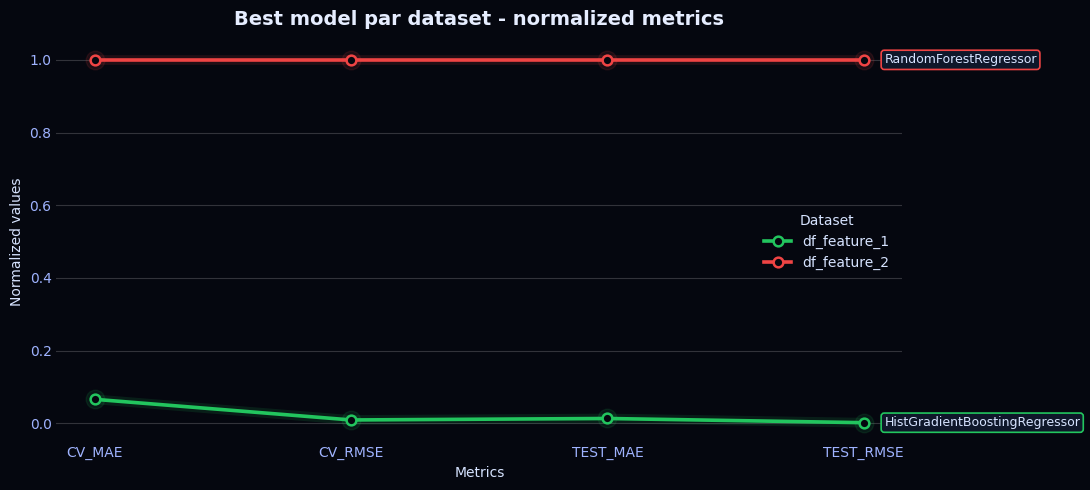

In [52]:
plot_best_df(df_best_global)

- The most performant dataset is **df_feature_1**, even though it contains fewer explanatory variables.  
  However, it has a significantly larger volume of data (approximately 7 times more observations), which improves the model's generalization ability and reduces the risk of overfitting.

- Both in cross-validation and on the test set, the best model trained on **df_feature_1** achieves significantly lower MAE and RMSE values.  
  This indicates a better ability to minimize prediction error and confirms that, in this case, the quantity of data has a stronger impact than the number of features.

The dataset **df_feature_1** is retained based on its superior performance across evaluation metrics, both in cross-validation and on the test set.

### Best model selection for df_feature_1 using an extended hyperparameter search

-   Preprocessing

In [53]:
param_grid_2 = [
    # Linear model : SGDRegressor
    {
        "model": [SGDRegressor(max_iter=20000, tol=1e-3, random_state=42)],
        "model__loss": ["huber"],
        "model__penalty": ["l2", "elasticnet"],
        "model__alpha": [1e-5, 1e-4],
        "model__l1_ratio": [0.15],
        "model__epsilon": [1.05, 1.35],
    },

    # bagging model : RandomForestRegressor
    {
        "model": [RandomForestRegressor(random_state=42, n_jobs=1)],
        "model__n_estimators": [200],
        "model__max_depth": [None, 12],
        "model__min_samples_leaf": [1, 10],
        "model__max_features": ["sqrt", 0.5],
    },

    # Boosting model: HistGradientBoosting
    {
        "model": [HistGradientBoostingRegressor(random_state=42)],
        "model__learning_rate": [0.03, 0.08],
        "model__max_iter": [200],
        "model__max_depth": [3],
        "model__max_leaf_nodes": [31, 63],
        "model__min_samples_leaf": [20, 50],
        "model__l2_regularization": [0.0],
    },
]

-   Estimate model training duration

In [54]:
# Splir dataset
splits = split(df_feature_1)

X_tune = splits["X_tune"]
y_tune = splits["y_tune"]
tscv = splits["tscv"]

# Estimate training time for the full hyperparameter grid
estimer_temps(
    preprocessor=prepro_f1,
    param_grid=param_grid_2,
    X=X_tune,
    y=y_tune,
    cv=tscv
)

 Estimate duration : 47.55 minutes (0.79 heures)


-  Training

In [55]:
# Train models
best_model_f1, row_f1, recap_f1, recap_test_f1, grid_f1, kpi_f1, splits_f1 = entrainement(
    df=df_feature_1,
    preprocessor=prepro_f1,
    split_fn=split,
    param_grid=param_grid_2,
    dataset_name="df_feature_1"
)

Fitting 5 folds for each of 24 candidates, totalling 120 fits



=== Best Model ===



,model_name,dataset,CV_MAE,CV_MAE_STD,CV_RMSE,CV_RMSE_STD,TEST_MAE,TEST_RMSE,best_params
0,HistGradientBoostingRegressor,df_feature_1,0.423665,0.087448,0.851369,0.173768,0.277260,0.563725,{'model': HistGradientBoostingRegressor(learni...
1,RandomForestRegressor,df_feature_1,0.395217,0.094143,0.861840,0.163576,0.411289,0.616173,{'model': (DecisionTreeRegressor(max_features=...
2,SGDRegressor,df_feature_1,28.408870,14.234055,28.639314,14.255130,35.112201,35.199081,"{'model': SGDRegressor(epsilon=1.05, loss='hub..."


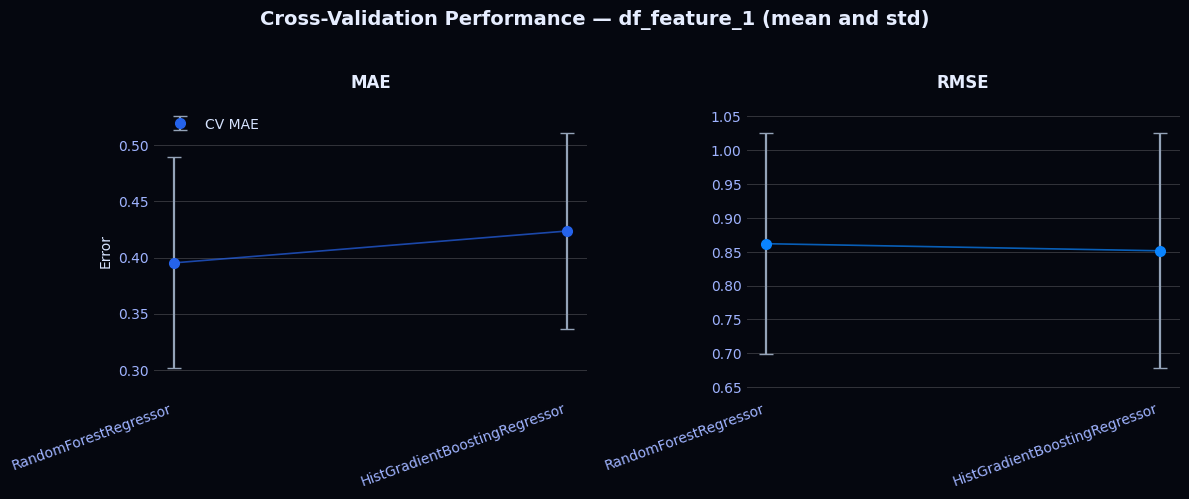

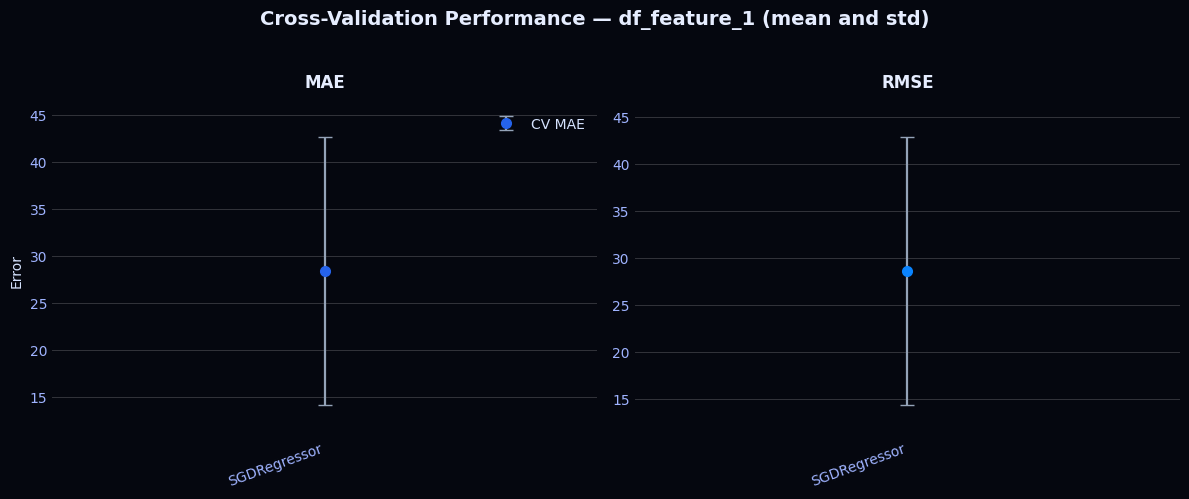

In [56]:
print("\n=== Best Model ===\n")
display(recap_f1)
plot_cv(recap_f1,models=["RandomForestRegressor","HistGradientBoostingRegressor"])
plot_cv(recap_f1,models="SGDRegressor")

The results show overall consistency between cross-validation and test performance, indicating good model generalization.

- RandomForestRegressor achieves the best overall performance, with the lowest MAE and RMSE on average.  
  The gap between cross-validation and test scores remains small, suggesting a stable model with a good bias-variance trade-off.

- SGDRegressor shows intermediate performance.  
  However, the variability in cross-validation is significantly higher, indicating strong sensitivity to data fluctuations.  
  Despite this, test performance remains close to the CV mean, suggesting no strong overfitting.

- HistGradientBoostingRegressor shows slightly higher average errors compared to RandomForest.  
  However, test scores remain within the cross-validation error range, indicating correct generalization but slightly lower predictive performance on this dataset.

-  Resource analysis

In [57]:
df_kpi_res = benchmark_model(
    df=df_feature_1,
    grid=best_grids["df_feature_1"],
    df_resume=recap_f1,
    split_fn=split,                 
    dataset_name="df_feature_1",
    batch_size=500,                 
    n_runs=40,
    warmup_runs=3
)



,dataset,model_name,infer_batch_size,infer_runs,predict_latency_ms_p50,predict_latency_ms_p95,predict_latency_ms_p99,throughput_rows_s,cpu_percent_avg_process_infer,cpu_percent_max_process_infer,ram_avg_mb_infer,ram_max_mb_infer,cpu_cores_logical,model_size_mb,model_load_time_ms
0,df_feature_1,HistGradientBoostingRegressor,500,40,9.53255,12.239965,12.754074,50479.288221,1397.700000,1979.5,559.169922,562.250000,32,0.268850,30.0842
1,df_feature_1,RandomForestRegressor,500,40,46.98630,47.979115,50.386954,10587.294146,96.939474,124.3,560.536904,561.316406,32,68.053881,73.7404
2,df_feature_1,SGDRegressor,500,40,7.18300,7.721705,8.792831,68845.393898,87.466667,123.7,596.873047,600.023438,32,0.024151,1.1353


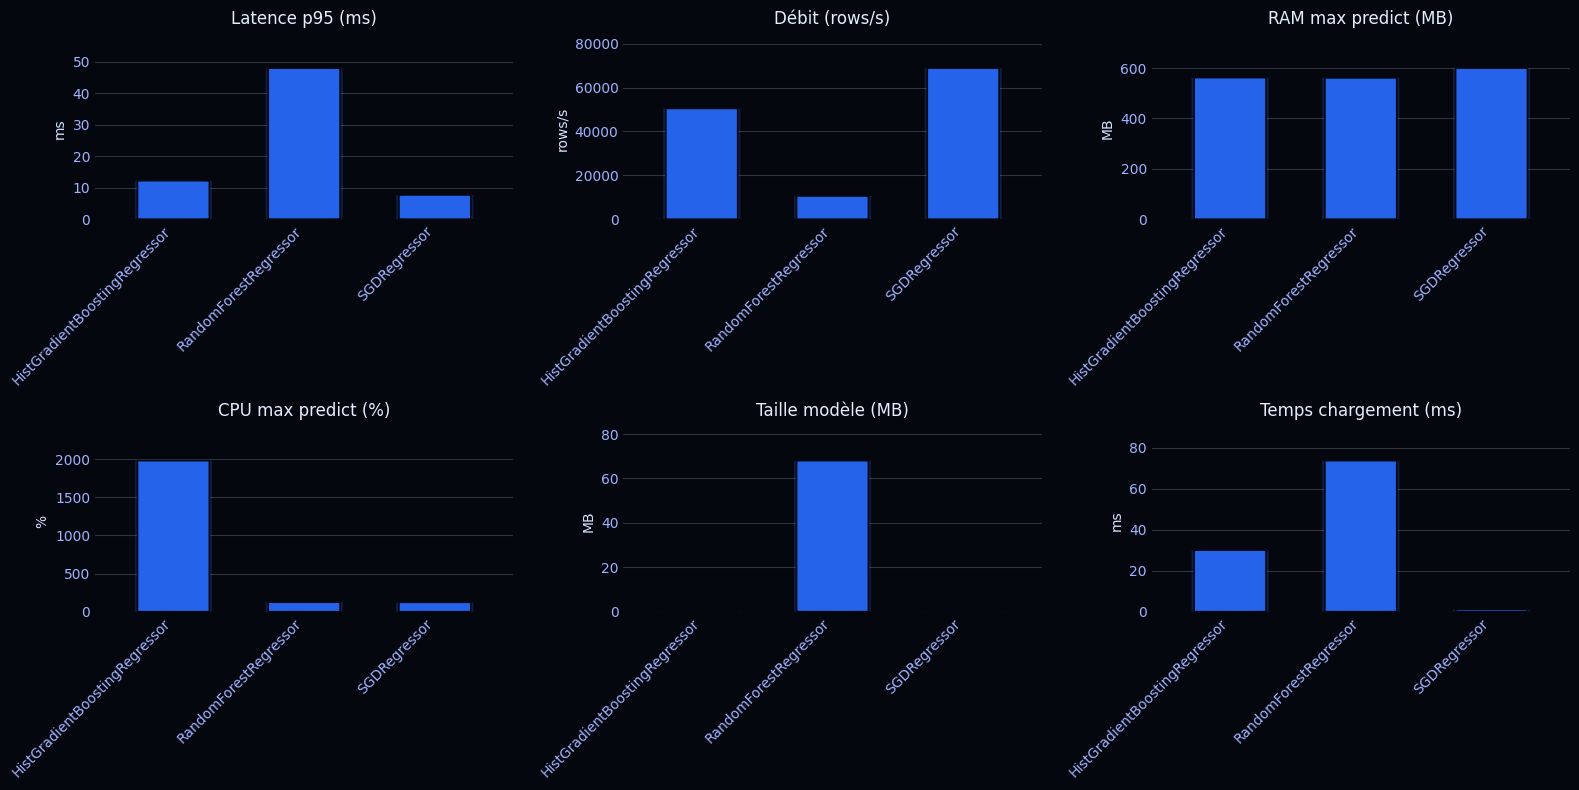

In [58]:
display(df_kpi_res)
plot_benchmark_global(df_kpi_res)

- SGDRegressor is the lightest and fastest model.  
  It shows low latency (15 ms), very high throughput (60k rows/s), and a negligible model size (<1 MB).  
  Its loading time is also extremely fast, making it well suited for low-latency or real-time applications.

- RandomForestRegressor is significantly more expensive at inference time.  
  Latency is higher (35 ms), throughput is lower (15k rows/s), and the model size is large (70 MB), leading to longer loading times (80 ms).  
  Despite this, it delivers the best predictive performance, illustrating the classic trade-off between accuracy and computational cost.

- HistGradientBoostingRegressor provides a strong compromise.  
  It achieves the lowest latency (12 ms) and high throughput (~50k rows/s), while maintaining a very small model size (<1 MB).  
  However, CPU usage is significantly higher, likely due to internal parallelization during inference.  
  It therefore represents a good trade-off between inference speed and predictive performance, with a higher computational cost in terms of CPU.

The RandomForestRegressor is retained as it delivers the best predictive performance while maintaining consistent results between cross-validation and the test set.

### Entrainnement du meilleur modèle

-   Preprocessing

In [59]:
param_grid_3 = [
    {
        # bagging model : RandomForestRegressor
        "model": [RandomForestRegressor(random_state=42, n_jobs=1)],
        "model__n_estimators": [300, 500],
        "model__max_depth": [10, 20, 30, None],
        "model__min_samples_leaf": [1, 5],
        "model__min_samples_split": [2, 10],
        "model__max_features": ["sqrt", 0.5],
        "model__bootstrap": [True]
    }
]


-   Estimate model training duration

In [60]:
# Split dataset
splits = split(df_feature_1)

X_tune = splits["X_tune"]
y_tune = splits["y_tune"]
tscv = splits["tscv"]

# Estimate training time for the full hyperparameter grid
estimer_temps(
    preprocessor=prepro_f1,
    param_grid=param_grid_3,
    X=X_tune,
    y=y_tune,
    cv=tscv,
    model ="rf"
)

 Estimate duration : 40.99 minutes (0.68 heures)


-   Entrainement

In [61]:
# Train model
best_model_f1_rf, row_f1_rf, recap_f1_rf,recap_test_f1_rf, grid_f1_rf, kpi_f1_rf, splits_f1_rf = entrainement(
    df=df_feature_1,
    preprocessor=prepro_f1,
    split_fn=split,
    param_grid=param_grid_3,
    dataset_name="df_feature_1",
    n_jobs= -1
)

Fitting 5 folds for each of 64 candidates, totalling 320 fits


In [62]:
print("\n=== Best Model ===\n")
display(row_f1_rf)


=== Best Model ===



{'dataset': 'df_feature_1',
 'best_model': 'RandomForestRegressor',
 'CV_MAE': np.float64(0.39583872514860585),
 'CV_MAE_STD': np.float64(0.09727518402735794),
 'CV_RMSE': np.float64(0.8615471732631826),
 'CV_RMSE_STD': np.float64(0.1654603461436886),
 'TEST_MAE': 0.4095647344569175,
 'TEST_RMSE': np.float64(0.6145572826379082),
 'best_params': {'model': RandomForestRegressor(max_features=0.5, n_estimators=300, n_jobs=1,
                        random_state=42),
  'model__bootstrap': True,
  'model__max_depth': None,
  'model__max_features': 0.5,
  'model__min_samples_leaf': 1,
  'model__min_samples_split': 2,
  'model__n_estimators': 300}}

- Analyse de la courbe d'apprentissage du meilleur modèle

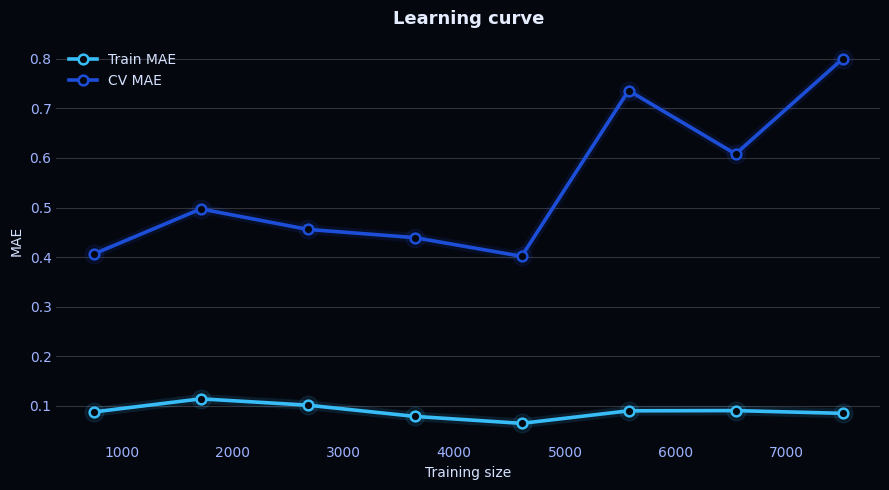

In [63]:
X_tune = splits_f1_rf["X_tune"]
y_tune = splits_f1_rf["y_tune"]
tscv   = splits_f1_rf["tscv"]

# Plot learning curve
plot_learning_curve_ts(
    best_model=best_model_f1_rf,
    X=X_tune,
    y=y_tune,
    tscv=tscv
)


- The learning curve shows that with a small amount of data, the model exhibits strong overfitting, as indicated by a large gap between training and cross-validation errors.

- As the training size increases, generalization improves significantly, with the gap narrowing and performance stabilizing around 5,000 observations. Beyond this point, additional data provides diminishing returns.

### Model interpretation

- SHAP preparation

In [64]:
# Extract test dataset from split results
X_test = splits_f1_rf["X_test"]
y_test = splits_f1_rf["y_test"]

# Sample a subset of test data to use as SHAP background dataset
X_background = X_test.sample(100)

display(X_test.columns)
display(X_background.columns)

Index(['DATE', 'Style', 'price', 'Category', 'log_price', 'dlog_qty_SKU',
       'dlog_price_SKU', 'elasticite_rolling_SKU', 'dlog_qty_Style',
       'dlog_price_Style', 'elasticite_rolling_Style', 'dlog_qty_Category',
       'dlog_price_Category', 'elasticite_rolling_Category',
       'var_elasticite_rolling_SKU', 'var_elasticite_rolling_Style',
       'var_elasticite_rolling_Category',
       'flag_imputed_elasticite_rolling_SKU',
       'flag_imputed_var_elasticite_rolling_SKU',
       'flag_imputed_elasticite_rolling_Category',
       'flag_imputed_var_elasticite_rolling_Category',
       'flag_imputed_elasticite_rolling_Style',
       'flag_imputed_var_elasticite_rolling_Style', 'style_mean_qty',
       'basket_intensity_style_norm', 'basket_intensity_style_norm_plot',
       'year', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'week_sin',
       'week_cos', 'saison'],
      dtype='object')

Index(['DATE', 'Style', 'price', 'Category', 'log_price', 'dlog_qty_SKU',
       'dlog_price_SKU', 'elasticite_rolling_SKU', 'dlog_qty_Style',
       'dlog_price_Style', 'elasticite_rolling_Style', 'dlog_qty_Category',
       'dlog_price_Category', 'elasticite_rolling_Category',
       'var_elasticite_rolling_SKU', 'var_elasticite_rolling_Style',
       'var_elasticite_rolling_Category',
       'flag_imputed_elasticite_rolling_SKU',
       'flag_imputed_var_elasticite_rolling_SKU',
       'flag_imputed_elasticite_rolling_Category',
       'flag_imputed_var_elasticite_rolling_Category',
       'flag_imputed_elasticite_rolling_Style',
       'flag_imputed_var_elasticite_rolling_Style', 'style_mean_qty',
       'basket_intensity_style_norm', 'basket_intensity_style_norm_plot',
       'year', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'week_sin',
       'week_cos', 'saison'],
      dtype='object')

In [65]:
# Extract preprocessing step from the trained pipeline
pre = best_model_f1_rf.named_steps["preprocess"]

print("Type X_test:", type(X_test))
print("X_test columns:", list(X_test.columns)[:5], "...", len(X_test.columns))
print("pre.feature_names_in_:", list(pre.feature_names_in_)[:5], "...", len(pre.feature_names_in_))

# Identify missing features
missing = set(pre.feature_names_in_) - set(X_test.columns)

# Identify extra features
extra = set(X_test.columns) - set(pre.feature_names_in_)

# Print mismatched features
print("Missing:", missing)
print("Extra:", extra)
print("Extra:", extra)

Type X_test: <class 'pandas.core.frame.DataFrame'>
X_test columns: ['DATE', 'Style', 'price', 'Category', 'log_price'] ... 34
pre.feature_names_in_: ['DATE', 'Style', 'price', 'Category', 'log_price'] ... 34
Missing: set()
Extra: set()
Extra: set()


DEBUG transform_X type: <class 'pandas.core.frame.DataFrame'>
DEBUG cols: ['DATE', 'Style', 'price', 'Category', 'log_price', 'dlog_qty_SKU', 'dlog_price_SKU', 'elasticite_rolling_SKU', 'dlog_qty_Style', 'dlog_price_Style', 'elasticite_rolling_Style', 'dlog_qty_Category', 'dlog_price_Category', 'elasticite_rolling_Category', 'var_elasticite_rolling_SKU', 'var_elasticite_rolling_Style', 'var_elasticite_rolling_Category', 'flag_imputed_elasticite_rolling_SKU', 'flag_imputed_var_elasticite_rolling_SKU', 'flag_imputed_elasticite_rolling_Category', 'flag_imputed_var_elasticite_rolling_Category', 'flag_imputed_elasticite_rolling_Style', 'flag_imputed_var_elasticite_rolling_Style', 'style_mean_qty', 'basket_intensity_style_norm', 'basket_intensity_style_norm_plot', 'year', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'week_sin', 'week_cos', 'saison'] n= 34
DEBUG transform_X type: <class 'pandas.core.frame.DataFrame'>
DEBUG cols: ['DATE', 'Style', 'price', 'Category', 'log_price', 'dlog_qty

 96%|=================== | 193/200 [00:18<00:00]       

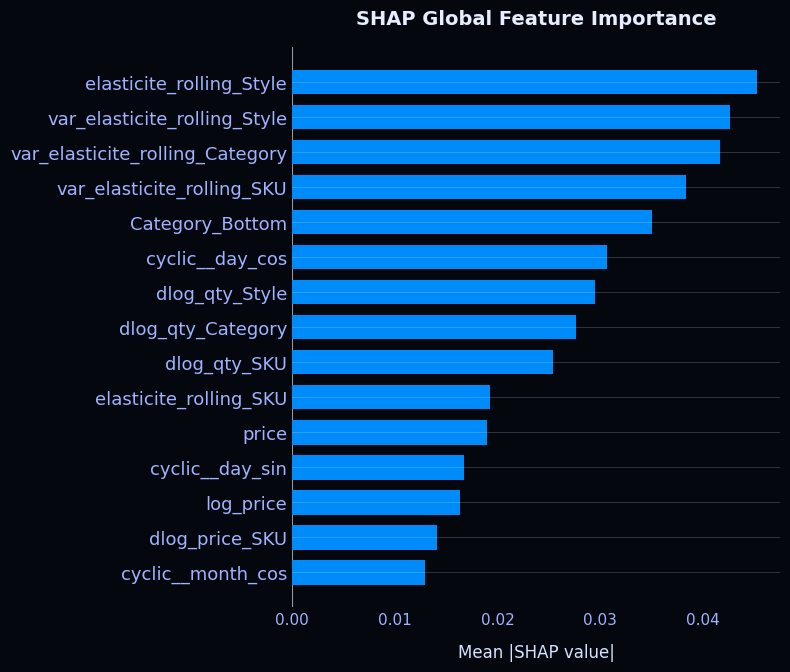

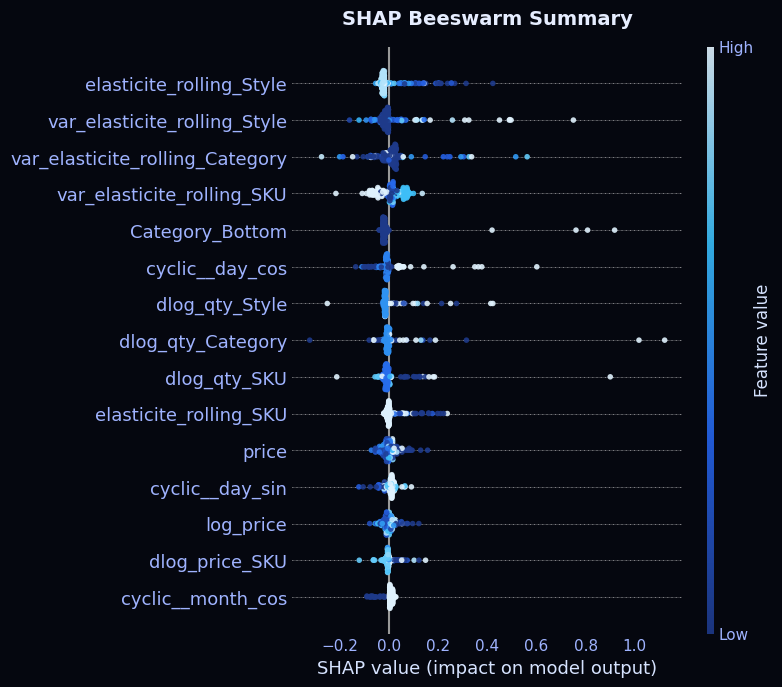

In [66]:
shap_summary(
    best_pipeline=best_model_f1_rf,
    X_background=X_background,
    X_explain=X_test,
    sample_explain=200,
    background_size=100
)

-   For Global Feature Importance :
    -   Elasticity features are the most important: the model mainly learns price sensitivity.
    -   Demand variations and time effects also matter.
    -   Raw price has low impact: its effect is captured through elasticity features.

-   For Beeswarm Summary :
    -   Elasticity features dominate: high values strongly increase the prediction, while low values decrease it.
    -   Demand variations and time effects also influence the prediction, but in a more moderate and dispersed way.
    -   Price has limited impact, as its effect is already captured through elasticity features.

- SHAP local

DEBUG transform_X type: <class 'pandas.core.frame.DataFrame'>
DEBUG cols: ['DATE', 'Style', 'price', 'Category', 'log_price', 'dlog_qty_SKU', 'dlog_price_SKU', 'elasticite_rolling_SKU', 'dlog_qty_Style', 'dlog_price_Style', 'elasticite_rolling_Style', 'dlog_qty_Category', 'dlog_price_Category', 'elasticite_rolling_Category', 'var_elasticite_rolling_SKU', 'var_elasticite_rolling_Style', 'var_elasticite_rolling_Category', 'flag_imputed_elasticite_rolling_SKU', 'flag_imputed_var_elasticite_rolling_SKU', 'flag_imputed_elasticite_rolling_Category', 'flag_imputed_var_elasticite_rolling_Category', 'flag_imputed_elasticite_rolling_Style', 'flag_imputed_var_elasticite_rolling_Style', 'style_mean_qty', 'basket_intensity_style_norm', 'basket_intensity_style_norm_plot', 'year', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'week_sin', 'week_cos', 'saison'] n= 34
DEBUG transform_X type: <class 'pandas.core.frame.DataFrame'>
DEBUG cols: ['DATE', 'Style', 'price', 'Category', 'log_price', 'dlog_qty

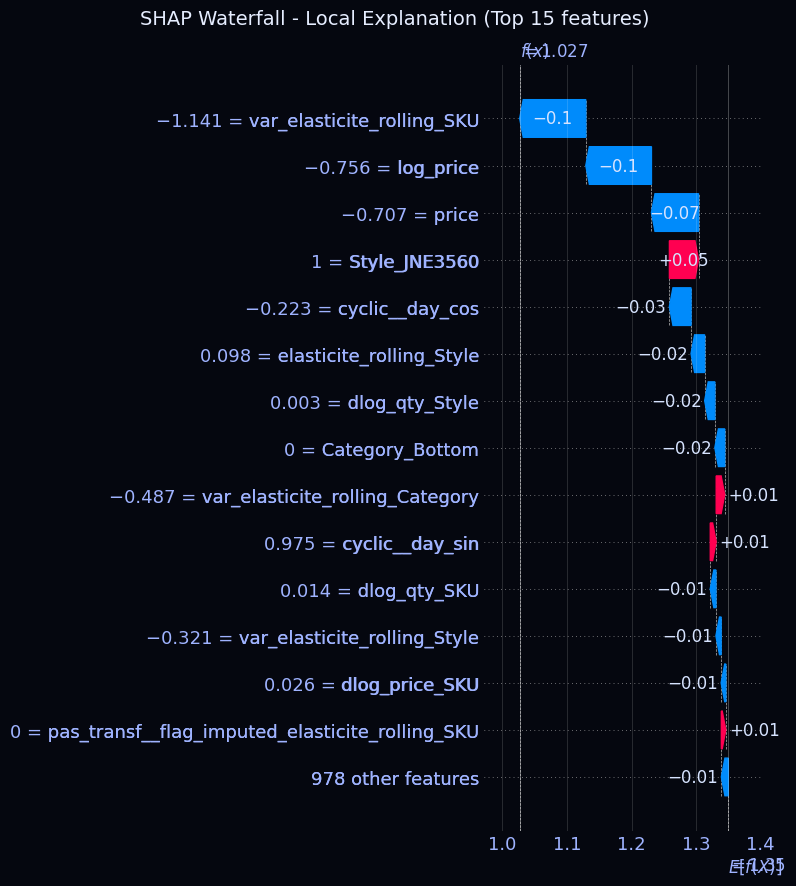

In [67]:
idx = np.argmax(np.abs(y_test - best_model_f1_rf.predict(X_test)))

shap_local_waterfall(
    best_model_f1_rf,
    X_background,
    X_test.iloc[[idx]]
)

-   Shap waterfall :
    -   Elasticity and price features strongly push the prediction downward for this instance.
    -   A few features (style, cyclic effects) slightly offset this by increasing the prediction.
    -   The final output is therefore mainly driven by dominant negative contributions.


- SHAP dependance

DEBUG transform_X type: <class 'pandas.core.frame.DataFrame'>
DEBUG cols: ['DATE', 'Style', 'price', 'Category', 'log_price', 'dlog_qty_SKU', 'dlog_price_SKU', 'elasticite_rolling_SKU', 'dlog_qty_Style', 'dlog_price_Style', 'elasticite_rolling_Style', 'dlog_qty_Category', 'dlog_price_Category', 'elasticite_rolling_Category', 'var_elasticite_rolling_SKU', 'var_elasticite_rolling_Style', 'var_elasticite_rolling_Category', 'flag_imputed_elasticite_rolling_SKU', 'flag_imputed_var_elasticite_rolling_SKU', 'flag_imputed_elasticite_rolling_Category', 'flag_imputed_var_elasticite_rolling_Category', 'flag_imputed_elasticite_rolling_Style', 'flag_imputed_var_elasticite_rolling_Style', 'style_mean_qty', 'basket_intensity_style_norm', 'basket_intensity_style_norm_plot', 'year', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'week_sin', 'week_cos', 'saison'] n= 34
DEBUG transform_X type: <class 'pandas.core.frame.DataFrame'>
DEBUG cols: ['DATE', 'Style', 'price', 'Category', 'log_price', 'dlog_qty

 99%|===================| 493/500 [00:43<00:00]        

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

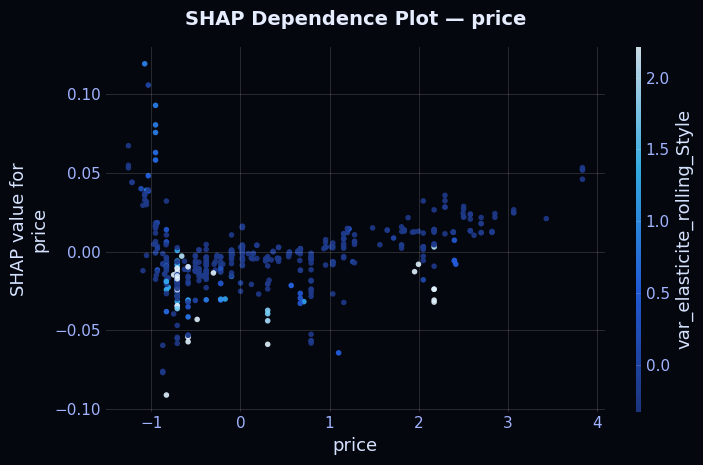

In [69]:
shap_dependence(
    best_pipeline=best_model_f1_rf,
    X_background=X_background,
    X_explain=X_test,
    feature="price",              
    interaction_feature="auto"   
)

-   Shap dependence :
    -   Price has a weak and non-structured effect on the prediction.
    -   Its impact varies depending on elasticity: for some observations, it slightly increases or decreases the prediction.
    -   This confirms that price effect is context-dependent (elasticity) rather than a direct relationship.

-   PDP et ICE

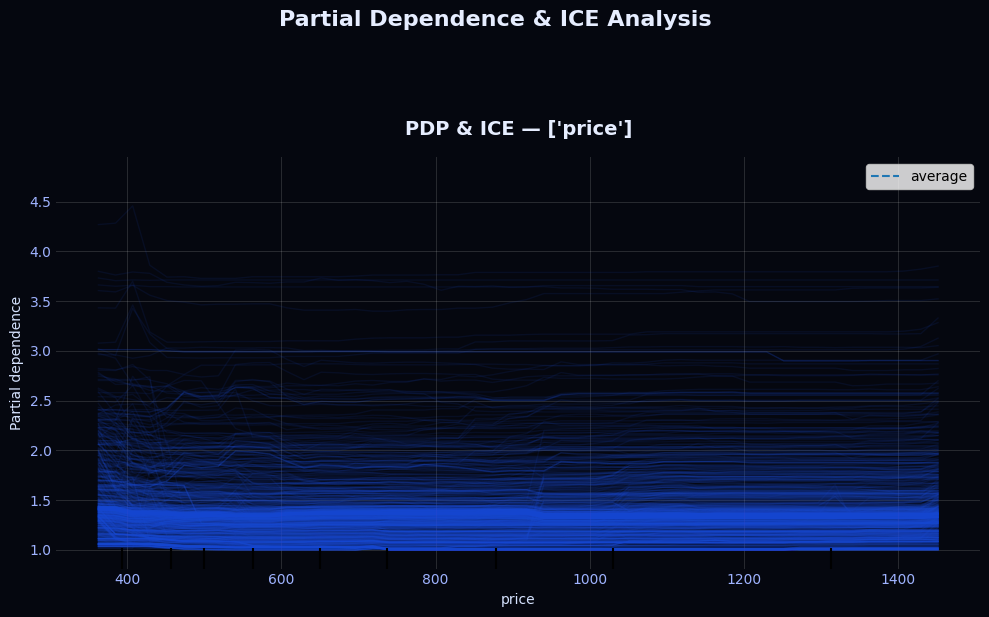

In [70]:
plot_pdp_ice(
    best_model_f1_rf,
    X_test,
    features=["price"]
)

-   PDP et ICE :
    -   Price has a weak and globally stable average effect on the prediction.
    -   Individual curves (ICE) show strong heterogeneity: the impact of price varies across observations.
    -   This confirms that price effect is context-dependent rather than driven by a single average relationship.

Sauvegarde du modèle

In [71]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

filename = f"best_model_{timestamp}.joblib"

artifact = {
    "pipeline": best_model_f1_rf,
    "dataset": df_feature_1,
    "best_params": best_model_f1_rf.get_params(),
    "metrics": {
        "CV_MAE": row_f1_rf["CV_MAE"],
        "CV_RMSE": row_f1_rf["CV_RMSE"],
        "TEST_MAE": row_f1_rf["TEST_MAE"],
        "TEST_RMSE": row_f1_rf["TEST_RMSE"],
    },
    "training_kpis": kpi_f1_rf,
    "timestamp": timestamp  
}

joblib.dump(artifact, filename)

print(f"Modèle sauvegardé : {filename}")


Modèle sauvegardé : best_model_20260401_160834.joblib
